In [1]:
import os.path as op
import pickle
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from scipy.stats import spearmanr
import pandas as pd
from scipy.ndimage import gaussian_filter1d
import mne
from scipy import stats
from functools import partial

In [2]:
json_file = "settings.json"
with open(json_file) as pipeline_file:
    parameters = json.load(pipeline_file)
path = parameters["dataset_path"]

In [3]:
epoch_types=['STIM','RESP']
condition_names=['SHORT','LONG']

In [4]:
td_color=np.array([27,158,119])/255.0
asd_color=np.array([117,112,179])/255.0

In [5]:
all_bursts = {
    'subject_id': [],
    'group': [],
    'epoch_type': [],
    'condition': [],
    'cluster': [],
    'channel': [],
    'trial': [],
    'waveform': np.zeros((0, 156)),
    'waveform_times': [],
    'peak_freq': [],
    'peak_amp_iter': [],
    'peak_amp_base': [],
    'peak_time': [],
    'peak_adjustment': [],
    'fwhm_freq': [],
    'fwhm_time': [],
    'polarity': [],
}

all_beta_power={
    hemi: {        
        epo_type: {
            condition_name: [] for condition_name in condition_names
        } for epo_type in epoch_types
    } for hemi in ['ipsi','contra']
}
power_time=None

df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_COMO.csv'))
for subject_id, group in df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None):
    subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
    fname = op.join(subject_data_dir, f'{subject_id}_beta_power.npz')
    if op.exists(fname):
        data = np.load(fname, allow_pickle=True)
        subj_beta_power = data['all_beta_pow'].item()
        for hemi in ['ipsi','contra']:
            for epo_type in epoch_types:
                for condition_name in condition_names:
                    all_beta_power[hemi][epo_type][condition_name].append(np.mean(subj_beta_power[hemi][epo_type][condition_name],axis=0))
        power_time = data['time']

    fname = op.join(subject_data_dir, f'{subject_id}_bursts.pickle')
    if op.exists(fname):
        with open(fname,'rb') as file:
            bursts=pickle.load(file)
        for key in bursts.keys():
            if key=='waveform_times':
                all_bursts[key] = bursts[key]
            elif key=='waveform':
                all_bursts[key] = np.vstack([all_bursts[key], bursts[key]])
            else:
                all_bursts[key] = np.hstack([all_bursts[key], bursts[key]])
                
df = pd.read_csv(op.join(path, 'data_v2', 'GOGO_Demographics_2025_Driving.csv'))
for subject_id, group in df.loc[:, ["ParticipantID", "Status"]].itertuples(index=False, name=None):
    subject_data_dir=op.join('/home/common/bonaiuto/gogo_bursts/derivatives_v2/processed',subject_id)
    fname = op.join(subject_data_dir, f'{subject_id}_beta_power.npz')
    if op.exists(fname):
        data = np.load(fname, allow_pickle=True)
        subj_beta_power = data['all_beta_pow'].item()
        for hemi in ['ipsi','contra']:
            for epo_type in epoch_types:
                for condition_name in condition_names:
                    all_beta_power[hemi][epo_type][condition_name].append(np.mean(subj_beta_power[hemi][epo_type][condition_name],axis=0))
        power_time = data['time']

    fname = op.join(subject_data_dir, f'{subject_id}_bursts.pickle')
    if op.exists(fname):
        with open(fname,'rb') as file:
            bursts=pickle.load(file)
        for key in bursts.keys():
            if key=='waveform_times':
                all_bursts[key] = bursts[key]
            elif key=='waveform':
                all_bursts[key] = np.vstack([all_bursts[key], bursts[key]])
            else:
                all_bursts[key] = np.hstack([all_bursts[key], bursts[key]])

In [6]:
td_idx=all_bursts['group']=='TD'
asd_idx=all_bursts['group']=='ASD'
stim_idx = all_bursts['epoch_type']=='STIM'
resp_idx = all_bursts['epoch_type']=='RESP'
hemi_idx = all_bursts['cluster']=='ipsi'

In [7]:
waveform_times=all_bursts['waveform_times']

In [8]:
subject_ids=np.unique(all_bursts['subject_id'])
groups={}
for subject_id in subject_ids:
    group=all_bursts['group'][all_bursts['subject_id']==subject_id][0].strip()
    groups[subject_id]=group
n_td=len(np.unique(all_bursts['subject_id'][td_idx]))
n_asd=len(np.unique(all_bursts['subject_id'][asd_idx]))
print(f'N typical={n_td}')
print(f'N ASD={n_asd}')

N typical=33
N ASD=37


min=0.7256626258475446, max=0.9994215359327336


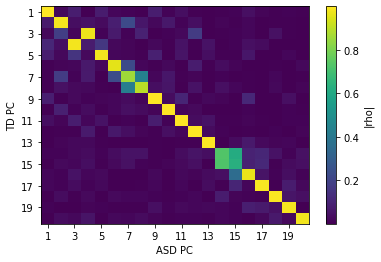

In [9]:
td_pca = PCA(n_components=20)
td_burst_std=RobustScaler().fit_transform(all_bursts['waveform'][hemi_idx & td_idx,:])
td_pca=td_pca.fit(td_burst_std)

asd_pca = PCA(n_components=20)
asd_burst_std=RobustScaler().fit_transform(all_bursts['waveform'][hemi_idx & asd_idx,:])
asd_pca=asd_pca.fit(asd_burst_std)

def spearman_correlation_matrix(pca1, pca2):
    eigenvectors1 = pca1.components_.T
    eigenvectors2 = pca2.components_.T
    n_components = eigenvectors1.shape[1]
    
    corr_matrix = np.zeros((n_components, n_components))
    for i in range(n_components):
        for j in range(n_components):
            corr, _ = spearmanr(eigenvectors1[:, i], eigenvectors2[:, j])
            corr_matrix[i, j] = abs(corr)  # Absolute value of the Spearman correlation
    return corr_matrix

pca_corr_matrix = spearman_correlation_matrix(td_pca, asd_pca)
max_corrs=[]
for i in range(pca_corr_matrix.shape[0]):
    max_corrs.append(np.max(pca_corr_matrix[i,:]))
print(f'min={np.min(max_corrs)}, max={np.max(max_corrs)}')

plt.figure()
ax=plt.subplot(1,1,1)
im=ax.imshow(pca_corr_matrix, cmap='viridis', aspect='auto')
plt.colorbar(im, label="|rho|")
ax.set_xlabel('ASD PC')
ax.set_ylabel('TD PC')
ax.set_xticks(np.arange(0,20,2))
ax.set_xticklabels(np.arange(0,20,2)+1)
ax.set_yticks(np.arange(0,20,2))
_=ax.set_yticklabels(np.arange(0,20,2)+1)

In [22]:
def shuffle_array(array):
    X_array = array.copy()
    rows, columns = array.shape
    for col in range(columns):
        ixes = np.arange(0,rows)
        np.random.shuffle(ixes)
        X_array[:,col] = X_array[:,col][ixes]
    return X_array

def shuffle_array_range(array, ranges):
    X_array = []
    for x1, x2 in ranges:
        X = wvf[:,x1:x2]
        np.random.shuffle(X)
        X_array.append(X)
    return np.hstack(X_array)

def get_num_components(waveforms, n_comps):
    # robust scaling
    waveforms_scaled = RobustScaler().fit_transform(waveforms)

    # main PCA fitting
    pca_full = PCA(n_components=n_comps)
    pcs_full = pca_full.fit_transform(waveforms_scaled)
    var_full = pca_full.explained_variance_ratio_ 

    # robustness of pca components
    no_of_iter = 100
    pca_vars = []
    for i in range(no_of_iter):
        shuffled_wvf = shuffle_array(waveforms_scaled)

        pca_shuff = PCA(n_components=n_comps)
        pca_shuff.fit(shuffled_wvf)
        pca_vars.append(pca_shuff.explained_variance_ratio_)        
    del shuffled_wvf
    pca_vars=np.array(pca_vars)

    # getting the magic number
    results = np.sum(var_full>pca_vars, axis=0) / no_of_iter
    threshold=1-(.05/n_comps)
    PCS_to_analyse = np.where(results > threshold)[0]
    return PCS_to_analyse

shuffling_results=get_num_components(all_bursts['waveform'], 20)
print(f'Non-noise PCs: {shuffling_results}')

Non-noise PCs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]


In [10]:
shuffling_results=np.arange(16)

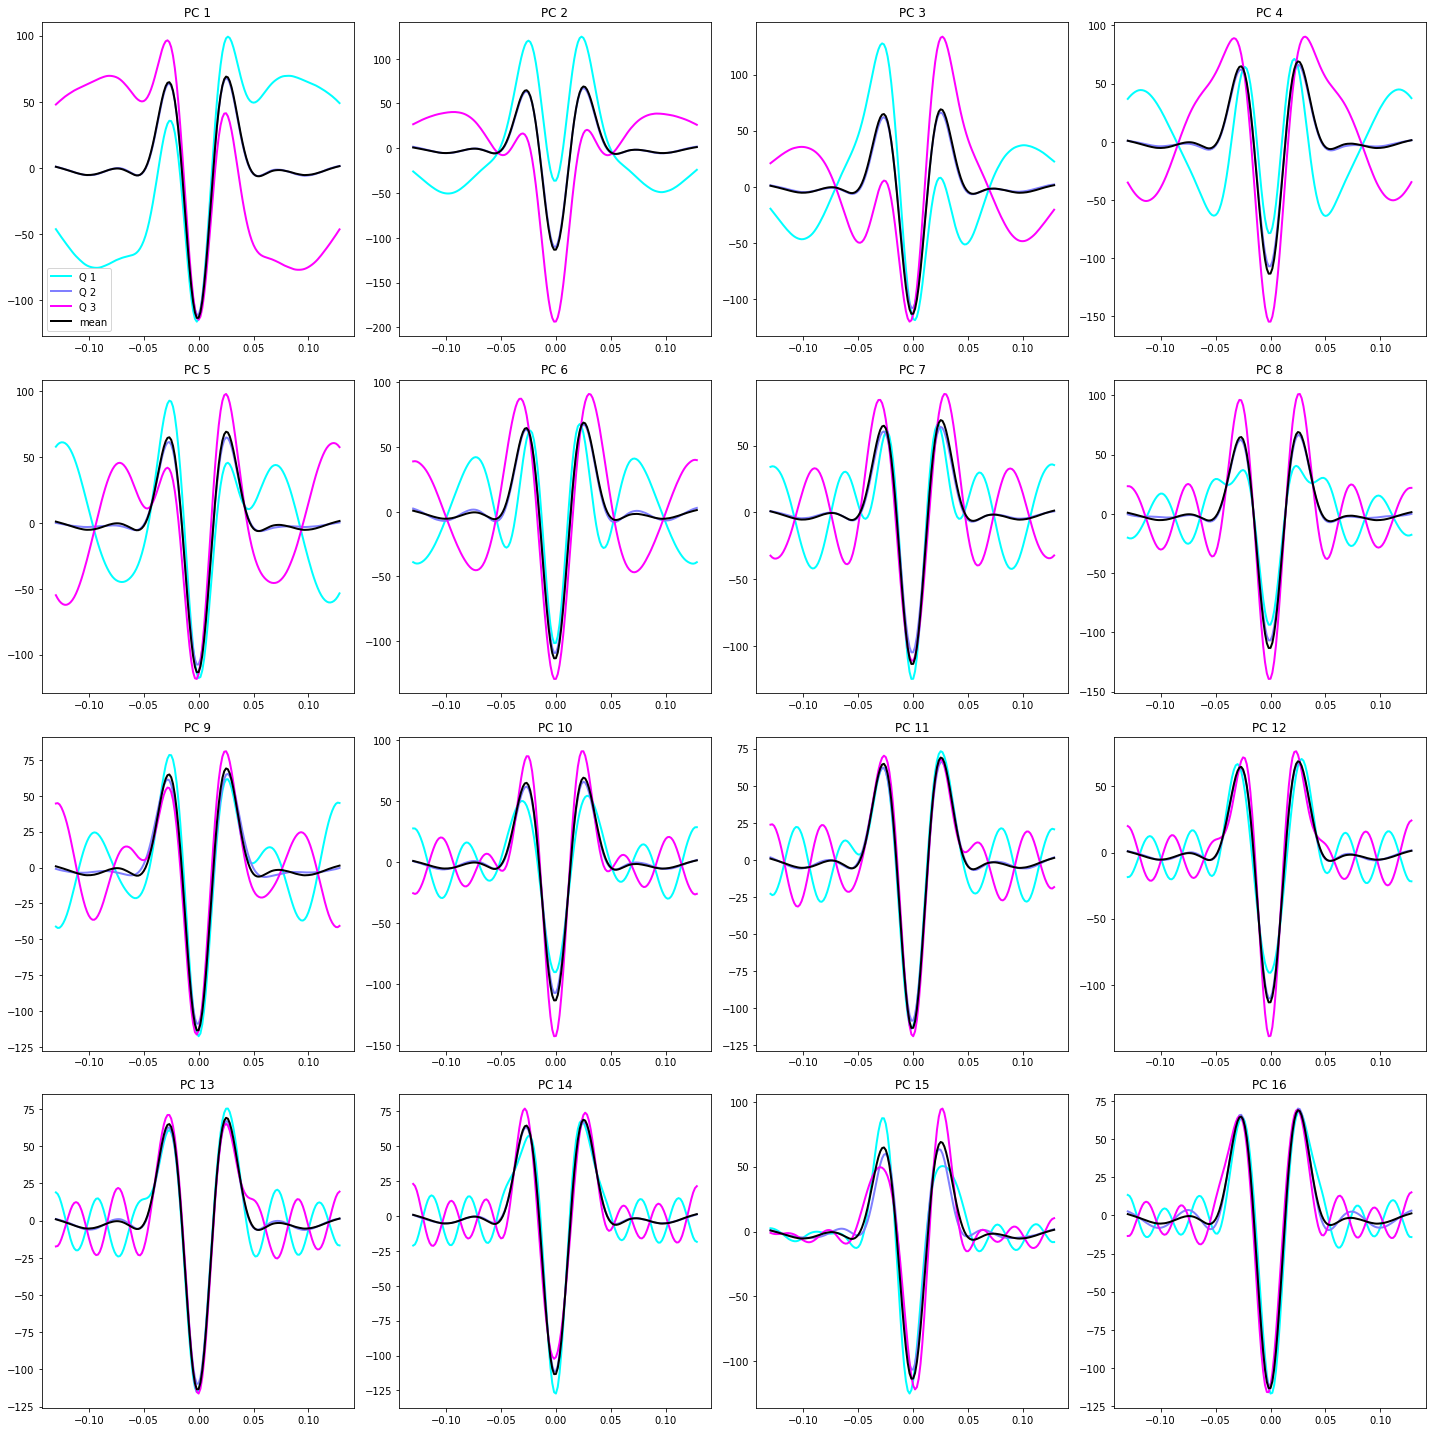

In [19]:
waveforms=all_bursts['waveform']
model = PCA(n_components=20)
burst_std=np.zeros(waveforms.shape)
for subject in np.unique(all_bursts['subject_id']):
    s_idx=all_bursts['subject_id']==subject
    burst_std[s_idx,:] = RobustScaler().fit_transform(waveforms[s_idx,:])
burst_std = RobustScaler().fit_transform(burst_std)
model.fit(burst_std)
pc_scores = model.transform(burst_std)  # all the bursts x 20 components
pc_labels = ["PC_{}".format(i+1) for i in range(pc_scores.shape[1])]

n_q=3
quartiles = np.linspace(0, 100, num=n_q+1)
quartiles = list(zip(quartiles[:-1], quartiles[1:]))
col_range = plt.cm.cool(np.linspace(0, 1, num=len(quartiles)))
mean_waveform = np.mean(waveforms, axis=0)

f, ax = plt.subplots(4, 4, figsize=(20, 20))
ax = ax.flatten()
for pc_ix, pc in enumerate(pc_labels[:len(shuffling_results)]):
    ax[pc_ix].set_title(pc.replace("_", " "))  # set the nice title
    scores = pc_scores[:,pc_ix]
    q_maps = []
    for q_ix, (b, e) in enumerate(quartiles):
        q_map = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))  # create a boolean map to select the waveforms
        q_mean = np.mean(waveforms[q_map], axis=0)
        ax[pc_ix].plot(waveform_times, q_mean/1e-15, lw=2, c=col_range[q_ix], label="Q {}".format(q_ix+1))
    ax[pc_ix].plot(waveform_times, mean_waveform/1e-15, lw=2, c="black", label="mean")
ax[0].legend(fontsize=10)

plt.tight_layout()
plt.show()

In [20]:
bin_width = 0.025
stim_time_bins = np.arange(-1.75, 1.75, bin_width)
resp_time_bins = np.arange(-1.75, 1.75, bin_width)

subject_score_ts={epoch_type: [] for epoch_type in epoch_types}
for subject_id in subject_ids:
    
    epoch_type='STIM'
    b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & (all_bursts['epoch_type']==epoch_type)
    pc_score_ts=[]
    for t_idx in range(len(stim_time_bins)-1):
        st=stim_time_bins[t_idx]
        en=stim_time_bins[t_idx+1]
        bb_idx=b_idx & (all_bursts['peak_time']>=st) & (all_bursts['peak_time']<=en)
        ms=np.nanmean(pc_scores[bb_idx,:],axis=0)
        pc_score_ts.append(ms)
    pc_score_ts=np.array(pc_score_ts)
    pc_score_ts = gaussian_filter1d(pc_score_ts, sigma=2.5, axis=0, mode="nearest")
    subject_score_ts[epoch_type].append(pc_score_ts)
    
    epoch_type='RESP'
    b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & (all_bursts['epoch_type']==epoch_type)
    pc_score_ts=[]
    for t_idx in range(len(resp_time_bins)-1):
        st=resp_time_bins[t_idx]
        en=resp_time_bins[t_idx+1]
        bb_idx=b_idx & (all_bursts['peak_time']>=st) & (all_bursts['peak_time']<=en)
        ms=np.nanmean(pc_scores[bb_idx,:],axis=0)
        pc_score_ts.append(ms)
    pc_score_ts=np.array(pc_score_ts)
    pc_score_ts = gaussian_filter1d(pc_score_ts, sigma=2.5, axis=0, mode="nearest")
    subject_score_ts[epoch_type].append(pc_score_ts)
for epoch_type in epoch_types:
    subject_score_ts[epoch_type]=np.array(subject_score_ts[epoch_type])

0.0017998200179982


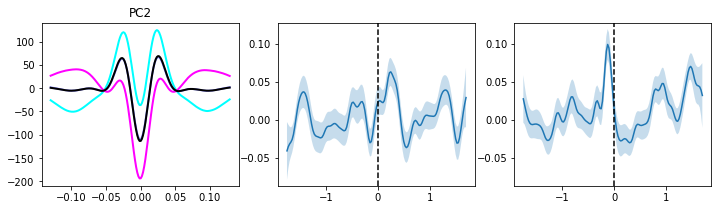

9.999000099990002e-05


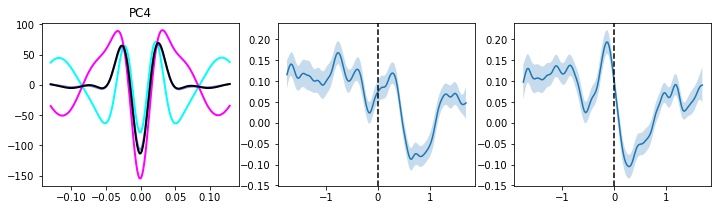

0.0006999300069993001


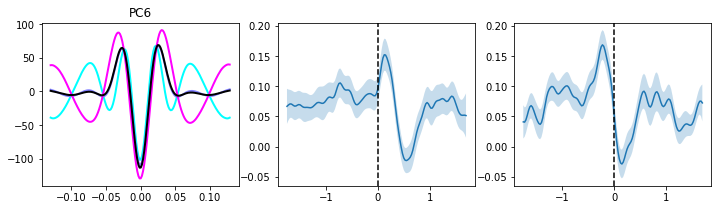

9.999000099990002e-05


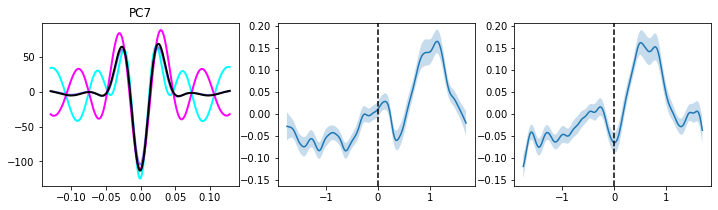

9.999000099990002e-05


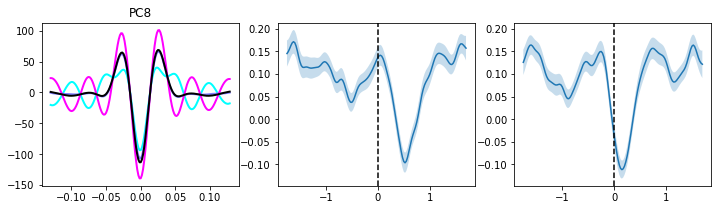

9.999000099990002e-05


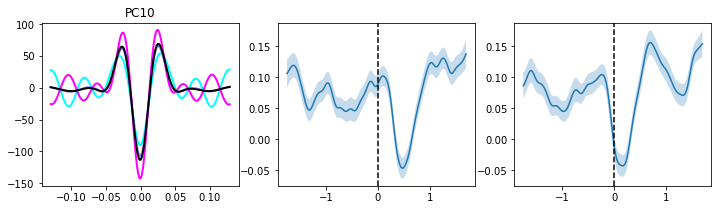

9.999000099990002e-05


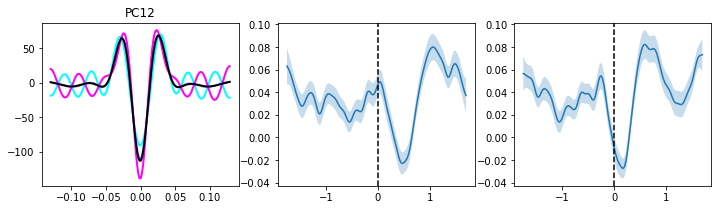

In [21]:
n_perm = 10000  # number of permutations

# Boolean mask for STIM baseline (pre-0)
stim_baseline_mask = (stim_time_bins[:-1] > -.5) & (stim_time_bins[:-1] < 0)
resp_mask = (resp_time_bins[:-1] > -.25) & (resp_time_bins[:-1] < .5)

task_pcs=[]

for pc in shuffling_results:
    m_stim = np.nanmean(subject_score_ts['STIM'], axis=0)[:, pc]
    se_stim = np.nanstd(subject_score_ts['STIM'], axis=0)[:, pc]/np.sqrt(subject_score_ts['STIM'].shape[0])
    m_resp = np.nanmean(subject_score_ts['RESP'], axis=0)[:, pc]
    se_resp = np.nanstd(subject_score_ts['RESP'], axis=0)[:, pc]/np.sqrt(subject_score_ts['RESP'].shape[0])
    
    # ------------------------------------------------------------------
    # Permutation test: is RESP temporal variance > STIM pre-0 variance?
    # ------------------------------------------------------------------
    stim_data = subject_score_ts['STIM'][:, :, pc]  # shape: n_subj × n_time_stim
    resp_data = subject_score_ts['RESP'][:, :, pc]  # shape: n_subj × n_time_resp

    # Per-subject temporal variances
    var_baseline = np.nanvar(stim_data[:, stim_baseline_mask], axis=1, ddof=1)
    var_resp = np.nanvar(resp_data[:, resp_mask], axis=1, ddof=1)

    diff = var_resp - var_baseline              # ?_i
    obs_stat = np.mean(diff)                    # observed mean difference across subjects

    # Sign-flip permutation for paired test
    null_stats = np.zeros(n_perm)
    for p in range(n_perm):
        signs = np.random.choice([1, -1], size=diff.shape[0])
        null_stats[p] = np.mean(diff * signs)

    # One-sided p-value: H1 = RESP variance > baseline variance
    p_val = (np.sum(null_stats >= obs_stat) + 1) / (n_perm + 1)
    
    if p_val*len(shuffling_results)<0.05:
        print(p_val)
        task_pcs.append(pc)
        
        plt.figure(figsize=(12,3))

        ax=plt.subplot(1,3,1)
        ax.set_title(f'PC{pc+1}')  # set the nice title
        scores = pc_scores[:,pc]
        q_maps = []
        for q_ix, (b, e) in enumerate(quartiles):
            q_map = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))  # create a boolean map to select the waveforms
            q_mean = np.mean(waveforms[q_map], axis=0)
            ax.plot(waveform_times, q_mean/1e-15, lw=2, c=col_range[q_ix], label="Q {}".format(q_ix+1))
        ax.plot(waveform_times, mean_waveform/1e-15, lw=2, c="black", label="mean")

        # STIM
        ax1 = plt.subplot(1,3,2)
        ax1.plot(stim_time_bins[:-1], m_stim)
        ax1.fill_between(stim_time_bins[:-1], m_stim-se_stim, m_stim+se_stim, alpha=0.25)
        ax1.axvline(0,color='k',linestyle='--')
        yl1=ax1.get_ylim()

        # RESP
        ax2 = plt.subplot(1,3,3)
        ax2.plot(resp_time_bins[:-1], m_resp)
        ax2.fill_between(resp_time_bins[:-1], m_resp-se_resp, m_resp+se_resp, alpha=0.25)
        ax2.axvline(0,color='k',linestyle='--')
        yl2=ax2.get_ylim()

        ymin=np.min([yl1[0], yl2[0]])
        ymax=np.max([yl1[1], yl2[1]])
        ax1.set_ylim(ymin, ymax)
        ax2.set_ylim(ymin, ymax)
        plt.show()

stat_fun(H1): min=-5.136007 max=5.884300
Running initial clustering …
Using 1177 thresholds from 0.00 to 5.88 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-14.067143 max=2.652264
Running initial clustering …
Using 2814 thresholds from 0.00 to 14.06 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.784854 max=8.818957
Running initial clustering …
Using 1764 thresholds from 0.00 to 8.81 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-12.075872 max=3.342179
Running initial clustering …
Using 2416 thresholds from 0.00 to 12.08 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.453417 max=8.234145
Running initial clustering …
Using 1647 thresholds from 0.00 to 8.23 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

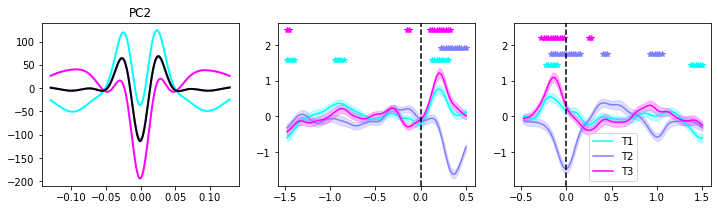

stat_fun(H1): min=-3.347340 max=6.834426
Running initial clustering …
Using 1367 thresholds from 0.00 to 6.83 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-8.227228 max=3.575003
Running initial clustering …
Using 1646 thresholds from 0.00 to 8.22 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.681774 max=6.894281
Running initial clustering …
Using 1379 thresholds from 0.00 to 6.89 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-6.595135 max=6.903440
Running initial clustering …
Using 1381 thresholds from 0.00 to 6.90 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-5.534106 max=7.522453
Running initial clustering …
Using 1505 thresholds from 0.00 to 7.52 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

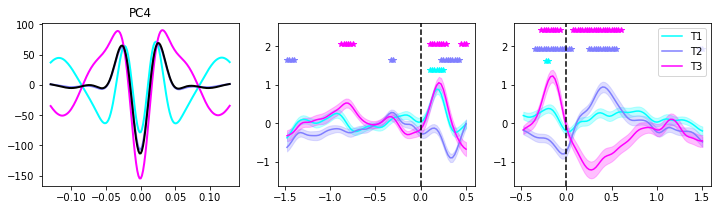

stat_fun(H1): min=-1.825966 max=3.153360
Running initial clustering …
Using 631 thresholds from 0.00 to 3.15 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-5.595647 max=1.856975
Running initial clustering …
Using 1120 thresholds from 0.00 to 5.59 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-4.337471 max=7.212411
Running initial clustering …
Using 1443 thresholds from 0.00 to 7.21 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-5.216580 max=3.326333
Running initial clustering …
Using 1044 thresholds from 0.00 to 5.21 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-5.260061 max=6.276117
Running initial clustering …
Using 1256 thresholds from 0.00 to 6.28 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

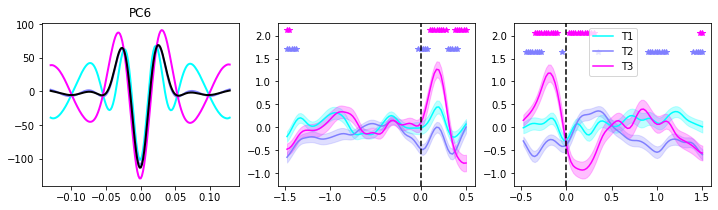

stat_fun(H1): min=-3.231326 max=2.264400
Running initial clustering …
Using 647 thresholds from 0.00 to 3.23 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-6.643624 max=4.200510
Running initial clustering …
Using 1329 thresholds from 0.00 to 6.64 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-4.089504 max=5.966614
Running initial clustering …
Using 1194 thresholds from 0.00 to 5.96 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-5.480752 max=3.194560
Running initial clustering …
Using 1097 thresholds from 0.00 to 5.48 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-4.004357 max=6.695776
Running initial clustering …
Using 1340 thresholds from 0.00 to 6.70 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

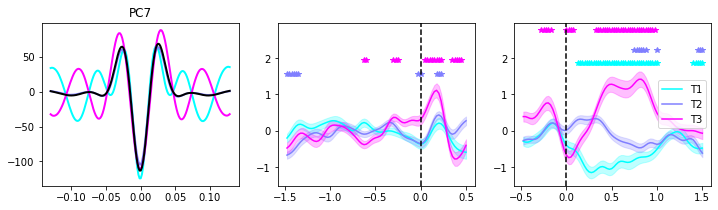

stat_fun(H1): min=-5.628472 max=3.385859
Running initial clustering …
Using 1126 thresholds from 0.00 to 5.62 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-4.170793 max=4.692822
Running initial clustering …
Using 939 thresholds from 0.00 to 4.69 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-8.881302 max=5.562949
Running initial clustering …
Using 1777 thresholds from 0.00 to 8.88 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-7.000751 max=4.180624
Running initial clustering …
Using 1401 thresholds from 0.00 to 7.00 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-10.414434 max=5.058713
Running initial clustering …
Using 2083 thresholds from 0.00 to 10.41 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

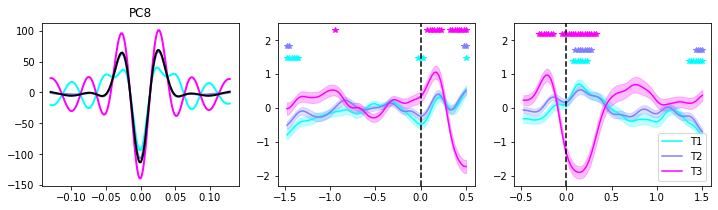

stat_fun(H1): min=-5.104176 max=3.682429
Running initial clustering …
Using 1021 thresholds from 0.00 to 5.10 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-5.257951 max=2.814200
Running initial clustering …
Using 1052 thresholds from 0.00 to 5.25 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-7.751337 max=5.518863
Running initial clustering …
Using 1551 thresholds from 0.00 to 7.75 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-5.317238 max=2.549033
Running initial clustering …
Using 1064 thresholds from 0.00 to 5.32 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-7.847066 max=5.428806
Running initial clustering …
Using 1570 thresholds from 0.00 to 7.84 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

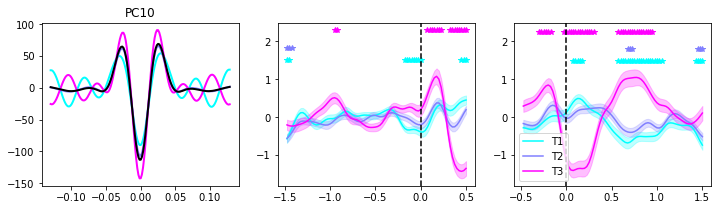

stat_fun(H1): min=-4.634844 max=4.898037
Running initial clustering …
Using 980 thresholds from 0.00 to 4.90 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-4.204924 max=3.528130
Running initial clustering …
Using 841 thresholds from 0.00 to 4.20 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-6.154484 max=3.788363
Running initial clustering …
Using 1231 thresholds from 0.00 to 6.15 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-4.165933 max=2.763541
Running initial clustering …
Using 834 thresholds from 0.00 to 4.17 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-6.326370 max=4.105076
Running initial clustering …
Using 1266 thresholds from 0.00 to 6.33 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

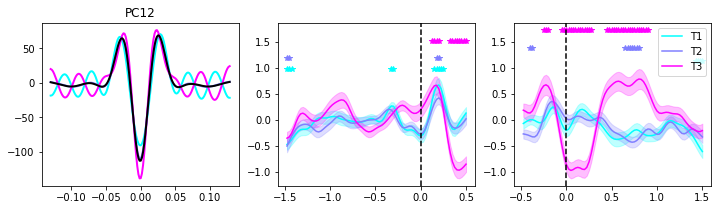

In [22]:
step = 100 / n_q
stim_plt_idx=(stim_time_bins[:-1]>=-1.5) & (stim_time_bins[:-1]<=.5)
resp_plt_idx=(resp_time_bins[:-1]>=-.5) & (resp_time_bins[:-1]<=1.5)

stim_time_plt=stim_time_bins[:-1][stim_plt_idx]
resp_time_plt=resp_time_bins[:-1][resp_plt_idx]

threshold_tfce = dict(start=0, step=0.005)

for pc in task_pcs:
    q_bins = np.percentile(pc_scores[:, pc], np.arange(0, 100 + step, step))

    q_rates_smoothed = {q: {epoch_type: [] for epoch_type in epoch_types} for q in range(n_q)}
    for subject_id in subject_ids:
        subj_idx = (all_bursts['subject_id'] == subject_id)

        subject_group=groups[subject_id].strip()

        stim_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & stim_idx
        resp_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & resp_idx

        for q in range(n_q):
            q_idx = ((pc_scores[:, pc] >= q_bins[q]) &
                     (pc_scores[:, pc] <= q_bins[q+1]))
            stim_trials = np.unique(all_bursts['trial'][stim_b_idx])
            resp_trials = np.unique(all_bursts['trial'][resp_b_idx])

            stim_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & stim_b_idx & q_idx],
                bins=stim_time_bins
            )
            resp_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & resp_b_idx & q_idx],
                bins=resp_time_bins
            )

            # Convert to rate
            stim_unsmoothed_rate = (stim_unsmoothed_rate / bin_width) / len(stim_trials)
            resp_unsmoothed_rate = (resp_unsmoothed_rate / bin_width) / len(resp_trials)

            stim_smoothed_rate = gaussian_filter1d(stim_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            resp_smoothed_rate = gaussian_filter1d(resp_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")

            base_idx = np.where((stim_time_bins>=-.75) & (stim_time_bins < -0.1))[0]
            base_rate = np.mean(stim_smoothed_rate[base_idx])
#             if base_rate>0:
#                 stim_smoothed_rate = (stim_smoothed_rate - base_rate)/base_rate*100
#                 resp_smoothed_rate = (resp_smoothed_rate - base_rate)/base_rate*100

#                 q_rates_smoothed[q]['STIM'].append(stim_smoothed_rate)
#                 q_rates_smoothed[q]['RESP'].append(resp_smoothed_rate)
            stim_smoothed_rate = (stim_smoothed_rate - base_rate)[stim_plt_idx]
            resp_smoothed_rate = (resp_smoothed_rate - base_rate)[resp_plt_idx]

            q_rates_smoothed[q]['STIM'].append(stim_smoothed_rate)
            q_rates_smoothed[q]['RESP'].append(resp_smoothed_rate)
            
    plt.figure(figsize=(12,3))

    ax=plt.subplot(1,3,1)
    ax.set_title(f'PC{pc+1}')  # set the nice title
    scores = pc_scores[:,pc]
    q_maps = []
    for q_ix, (b, e) in enumerate(quartiles):
        q_map = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))  # create a boolean map to select the waveforms
        q_mean = np.mean(waveforms[q_map], axis=0)
        ax.plot(waveform_times, q_mean/1e-15, lw=2, c=col_range[q_ix], label="Q {}".format(q_ix+1))
    ax.plot(waveform_times, mean_waveform/1e-15, lw=2, c="black", label="mean")

    # STIM
    ax1 = plt.subplot(1,3,2)
    for q in range(n_q):
        m_rate=np.mean(q_rates_smoothed[q]['STIM'],axis=0)
        se_rate=np.std(q_rates_smoothed[q]['STIM'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['STIM']))
        ax1.plot(stim_time_plt, m_rate, color=col_range[q])
        ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])
        
    for q in range(n_q):
        stim_data = np.array(q_rates_smoothed[q]['STIM'])
        stim_T_obs, stim_clusters, stim_cluster_p_values, H0 = mne.stats.permutation_cluster_1samp_test(
            stim_data,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        # Plot significant clusters
        yl = ax1.get_ylim()
        py = yl[1] + (q+1)*.05 * (yl[1] - 0)
        for p_idx, p_val in enumerate(stim_cluster_p_values):
            if p_val < 0.05:
                ax1.plot(stim_time_plt[p_idx], py, '*', color=col_range[q])
        
    ax1.axvline(0,color='k',linestyle='--')
    yl1=ax1.get_ylim()

    # RESP
    ax2 = plt.subplot(1,3,3)
    for q in range(n_q):
        m_rate=np.mean(q_rates_smoothed[q]['RESP'],axis=0)
        se_rate=np.std(q_rates_smoothed[q]['RESP'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['RESP']))
        ax2.plot(resp_time_plt, m_rate, color=col_range[q], label=f'T{q+1}')
        ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])
        
    for q in range(n_q):
        resp_data = np.array(q_rates_smoothed[q]['RESP'])
        resp_T_obs, resp_clusters, resp_cluster_p_values, H0 = mne.stats.permutation_cluster_1samp_test(
            resp_data,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        # Plot significant clusters
        yl = ax2.get_ylim()
        py = yl[1] + (q+1)*.05 * (yl[1] - 0)
        for p_idx, p_val in enumerate(resp_cluster_p_values):
            if p_val < 0.05:
                ax2.plot(resp_time_plt[p_idx], py, '*', color=col_range[q])
                
    ax2.legend()
    ax2.axvline(0,color='k',linestyle='--')
    yl2=ax2.get_ylim()

    ymin=np.min([yl1[0], yl2[0]])
    ymax=np.max([yl1[1], yl2[1]])
    ax1.set_ylim(ymin, ymax)
    ax2.set_ylim(ymin, ymax)
    plt.show()

stat_fun(H1): min=-2.524915 max=3.241780
Running initial clustering …
Using 649 thresholds from 0.00 to 3.24 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.928081 max=1.855964
Running initial clustering …
Using 386 thresholds from 0.00 to 1.93 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.770728 max=7.090423
Running initial clustering …
Using 1419 thresholds from 0.00 to 7.09 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-6.268125 max=2.461003
Running initial clustering …
Using 1254 thresholds from 0.00 to 6.27 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.124391 max=2.570370
Running initial clustering …
Using 515 thresholds from 0.00 to 2.57 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

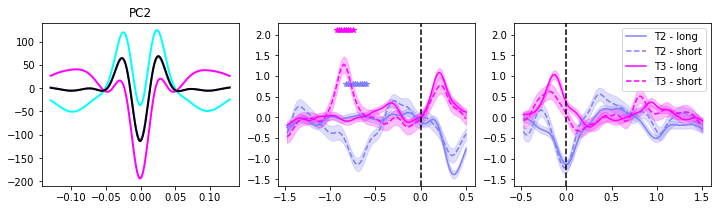

stat_fun(H1): min=-3.478285 max=1.456609
Running initial clustering …
Using 696 thresholds from 0.00 to 3.48 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.798699 max=1.468066
Running initial clustering …
Using 560 thresholds from 0.00 to 2.79 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-4.482482 max=2.455214
Running initial clustering …
Using 897 thresholds from 0.00 to 4.48 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.284337 max=5.956017
Running initial clustering …
Using 1192 thresholds from 0.00 to 5.96 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.868481 max=3.999480
Running initial clustering …
Using 800 thresholds from 0.00 to 4.00 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

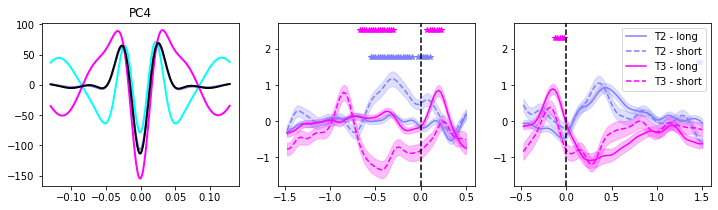

stat_fun(H1): min=-2.221531 max=2.522852
Running initial clustering …
Using 505 thresholds from 0.00 to 2.52 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.150224 max=1.582263
Running initial clustering …
Using 431 thresholds from 0.00 to 2.15 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.475032 max=2.735589
Running initial clustering …
Using 696 thresholds from 0.00 to 3.48 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.719647 max=4.962235
Running initial clustering …
Using 993 thresholds from 0.00 to 4.96 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.057349 max=2.129061
Running initial clustering …
Using 426 thresholds from 0.00 to 2.12 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

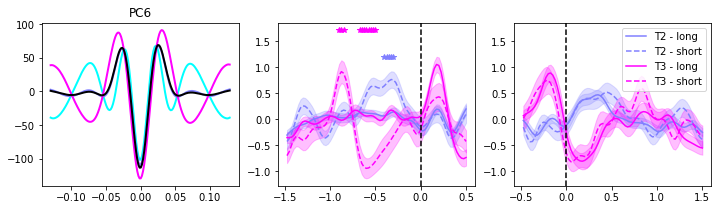

stat_fun(H1): min=-3.329265 max=5.499985
Running initial clustering …
Using 1100 thresholds from 0.00 to 5.50 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.260460 max=4.642169
Running initial clustering …
Using 929 thresholds from 0.00 to 4.64 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.471896 max=3.033667
Running initial clustering …
Using 695 thresholds from 0.00 to 3.47 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-4.458186 max=1.911943
Running initial clustering …
Using 892 thresholds from 0.00 to 4.46 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-4.704961 max=1.477616
Running initial clustering …
Using 941 thresholds from 0.00 to 4.70 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

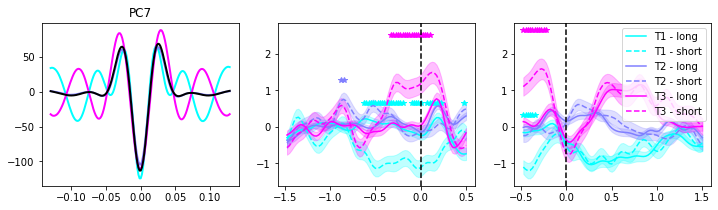

stat_fun(H1): min=-3.584149 max=1.829840
Running initial clustering …
Using 717 thresholds from 0.00 to 3.58 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.416423 max=2.129027
Running initial clustering …
Using 484 thresholds from 0.00 to 2.42 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.291010 max=2.232078
Running initial clustering …
Using 659 thresholds from 0.00 to 3.29 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.693820 max=6.965996
Running initial clustering …
Using 1394 thresholds from 0.00 to 6.96 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-4.502203 max=4.028154
Running initial clustering …
Using 901 thresholds from 0.00 to 4.50 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

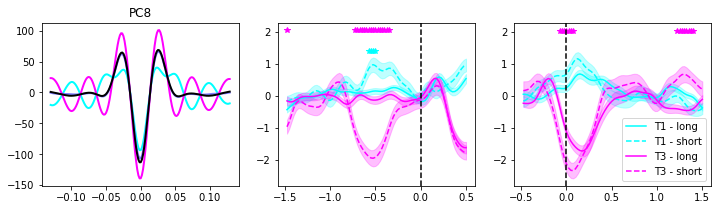

stat_fun(H1): min=-3.990644 max=2.518371
Running initial clustering …
Using 799 thresholds from 0.00 to 3.99 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.946541 max=1.560117
Running initial clustering …
Using 590 thresholds from 0.00 to 2.94 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.396713 max=1.668477
Running initial clustering …
Using 480 thresholds from 0.00 to 2.40 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.830611 max=7.607204
Running initial clustering …
Using 1522 thresholds from 0.00 to 7.61 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.376387 max=2.547732
Running initial clustering …
Using 510 thresholds from 0.00 to 2.54 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

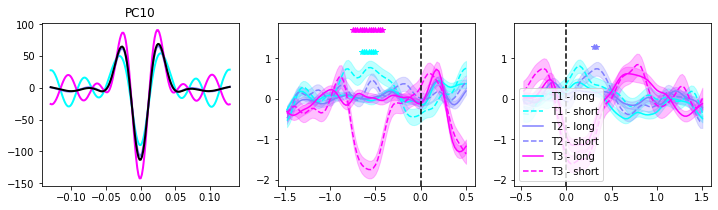

stat_fun(H1): min=-3.471256 max=2.588321
Running initial clustering …
Using 695 thresholds from 0.00 to 3.47 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.935389 max=1.453350
Running initial clustering …
Using 388 thresholds from 0.00 to 1.94 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.243614 max=2.181360
Running initial clustering …
Using 649 thresholds from 0.00 to 3.24 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.706656 max=6.638217
Running initial clustering …
Using 1328 thresholds from 0.00 to 6.63 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.303802 max=1.421852
Running initial clustering …
Using 461 thresholds from 0.00 to 2.30 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

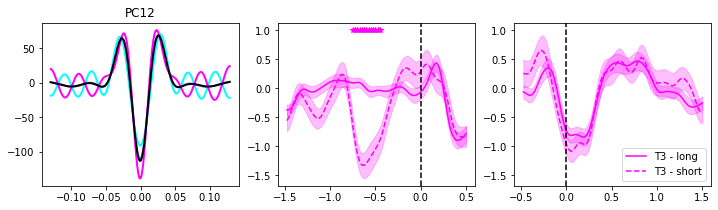

In [23]:
step = 100 / n_q

# Define custom paired t-test function (returns t-values only, no p-values)
def ttest_rel_no_p(x, y, axis=0):
    tvals, _ = stats.ttest_rel(x, y, axis=axis, nan_policy='omit')
    return tvals

paired_t = partial(ttest_rel_no_p, axis=0)
threshold_tfce = dict(start=0, step=0.005)


for pc in task_pcs:
    q_bins = np.percentile(pc_scores[:, pc], np.arange(0, 100 + step, step))

    q_rates_smoothed = {q: {epoch_type: {condition: [] for condition in condition_names} for epoch_type in epoch_types} for q in range(n_q)}
    for subject_id in subject_ids:
        subj_idx = (all_bursts['subject_id'] == subject_id)

        subject_group=groups[subject_id].strip()

        long_stim_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & stim_idx & (all_bursts['condition']=='LONG')
        short_stim_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & stim_idx & (all_bursts['condition']=='SHORT')
        long_resp_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & resp_idx & (all_bursts['condition']=='LONG')
        short_resp_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & resp_idx & (all_bursts['condition']=='SHORT')

        for q in range(n_q):
            q_idx = ((pc_scores[:, pc] >= q_bins[q]) &
                     (pc_scores[:, pc] <= q_bins[q+1]))
            long_stim_trials = np.unique(all_bursts['trial'][long_stim_b_idx])
            short_stim_trials = np.unique(all_bursts['trial'][short_stim_b_idx])
            long_resp_trials = np.unique(all_bursts['trial'][long_resp_b_idx])
            short_resp_trials = np.unique(all_bursts['trial'][short_resp_b_idx])

            long_stim_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & long_stim_b_idx & q_idx],
                bins=stim_time_bins
            )
            short_stim_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & short_stim_b_idx & q_idx],
                bins=stim_time_bins
            )
            long_resp_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & long_resp_b_idx & q_idx],
                bins=resp_time_bins
            )
            short_resp_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & short_resp_b_idx & q_idx],
                bins=resp_time_bins
            )

            # Convert to rate
            long_stim_unsmoothed_rate = (long_stim_unsmoothed_rate / bin_width) / len(long_stim_trials)
            short_stim_unsmoothed_rate = (short_stim_unsmoothed_rate / bin_width) / len(short_stim_trials)
            long_resp_unsmoothed_rate = (long_resp_unsmoothed_rate / bin_width) / len(long_resp_trials)
            short_resp_unsmoothed_rate = (short_resp_unsmoothed_rate / bin_width) / len(short_resp_trials)

            long_stim_smoothed_rate = gaussian_filter1d(long_stim_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            short_stim_smoothed_rate = gaussian_filter1d(short_stim_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            long_resp_smoothed_rate = gaussian_filter1d(long_resp_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            short_resp_smoothed_rate = gaussian_filter1d(short_resp_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")

            base_idx = np.where((stim_time_bins < -0.1))[0]
            base_rate = np.mean(long_stim_smoothed_rate[base_idx])
#             if base_rate>0:
#                 long_stim_smoothed_rate = (long_stim_smoothed_rate - base_rate)/base_rate*100
#                 short_stim_smoothed_rate = (short_stim_smoothed_rate - base_rate)/base_rate*100
#                 long_resp_smoothed_rate = (long_resp_smoothed_rate - base_rate)/base_rate*100
#                 short_resp_smoothed_rate = (short_resp_smoothed_rate - base_rate)/base_rate*100

#                 q_rates_smoothed[q]['STIM']['LONG'].append(long_stim_smoothed_rate)
#                 q_rates_smoothed[q]['STIM']['SHORT'].append(short_stim_smoothed_rate)
#                 q_rates_smoothed[q]['RESP']['LONG'].append(long_resp_smoothed_rate)
#                 q_rates_smoothed[q]['RESP']['SHORT'].append(short_resp_smoothed_rate)
            long_stim_smoothed_rate = (long_stim_smoothed_rate - base_rate)[stim_plt_idx]
            short_stim_smoothed_rate = (short_stim_smoothed_rate - base_rate)[stim_plt_idx]
            long_resp_smoothed_rate = (long_resp_smoothed_rate - base_rate)[resp_plt_idx]
            short_resp_smoothed_rate = (short_resp_smoothed_rate - base_rate)[resp_plt_idx]

            q_rates_smoothed[q]['STIM']['LONG'].append(long_stim_smoothed_rate)
            q_rates_smoothed[q]['STIM']['SHORT'].append(short_stim_smoothed_rate)
            q_rates_smoothed[q]['RESP']['LONG'].append(long_resp_smoothed_rate)
            q_rates_smoothed[q]['RESP']['SHORT'].append(short_resp_smoothed_rate)
            
    plt.figure(figsize=(12,3))

    ax=plt.subplot(1,3,1)
    ax.set_title(f'PC{pc+1}')  # set the nice title
    scores = pc_scores[:,pc]
    q_maps = []
    for q_ix, (b, e) in enumerate(quartiles):
        q_map = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))  # create a boolean map to select the waveforms
        q_mean = np.mean(waveforms[q_map], axis=0)
        ax.plot(waveform_times, q_mean/1e-15, lw=2, c=col_range[q_ix], label="Q {}".format(q_ix+1))
    ax.plot(waveform_times, mean_waveform/1e-15, lw=2, c="black", label="mean")

    # STIM
    ax1 = plt.subplot(1,3,2)
    # RESP
    ax2 = plt.subplot(1,3,3)    
    
    for q in range(n_q):
        stim_data = [np.array(q_rates_smoothed[q]['STIM']['LONG']), np.array(q_rates_smoothed[q]['STIM']['SHORT'])]
        stim_T_obs, stim_clusters, stim_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            stim_data,
            stat_fun=paired_t,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        resp_data = [np.array(q_rates_smoothed[q]['RESP']['LONG']), np.array(q_rates_smoothed[q]['RESP']['SHORT'])]
        resp_T_obs, resp_clusters, resp_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            resp_data,
            stat_fun=paired_t,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        
        if len(np.where(stim_cluster_p_values<0.05)[0])>1 or len(np.where(resp_cluster_p_values<0.05)[0])>1:
            m_rate=np.mean(q_rates_smoothed[q]['STIM']['LONG'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['STIM']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['STIM']['LONG']))
            ax1.plot(stim_time_plt, m_rate, color=col_range[q])
            ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            m_rate=np.mean(q_rates_smoothed[q]['STIM']['SHORT'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['STIM']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['STIM']['SHORT']))
            ax1.plot(stim_time_plt, m_rate, '--', color=col_range[q])
            ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            # Plot significant clusters
            yl = ax1.get_ylim()
            py = yl[1] + (q+1)*.1 * (yl[1] - 0)
            for p_idx, p_val in enumerate(stim_cluster_p_values):
                if p_val < 0.05:
                    ax1.plot(stim_time_plt[p_idx], py, '*', color=col_range[q])
                    
            
            m_rate=np.mean(q_rates_smoothed[q]['RESP']['LONG'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['RESP']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['RESP']['LONG']))
            ax2.plot(resp_time_plt, m_rate, color=col_range[q], label=f'T{q+1} - long')
            ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            m_rate=np.mean(q_rates_smoothed[q]['RESP']['SHORT'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['RESP']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['RESP']['SHORT']))
            ax2.plot(resp_time_plt, m_rate, '--', color=col_range[q], label=f'T{q+1} - short')
            ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            ax2.legend()
            # Plot significant clusters
            yl = ax2.get_ylim()
            py = yl[1] + (q+1)*.1 * (yl[1] - 0)
            for p_idx, p_val in enumerate(resp_cluster_p_values):
                if p_val < 0.05:
                    ax2.plot(resp_time_plt[p_idx], py, '*', color=col_range[q])
                    
    ax1.axvline(0,color='k',linestyle='--')
    yl1=ax1.get_ylim()

    ax2.axvline(0,color='k',linestyle='--')
    yl2=ax2.get_ylim()

    ymin=np.min([yl1[0], yl2[0]])
    ymax=np.max([yl1[1], yl2[1]])
    ax1.set_ylim(ymin, ymax)
    ax2.set_ylim(ymin, ymax)
    plt.show()

stat_fun(H1): min=-2.390702 max=1.601516
Running initial clustering …
Using 479 thresholds from 0.00 to 2.39 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.780727 max=2.360726
Running initial clustering …
Using 557 thresholds from 0.00 to 2.78 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.240962 max=6.452408
Running initial clustering …
Using 1291 thresholds from 0.00 to 6.45 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-5.147639 max=1.353842
Running initial clustering …
Using 1030 thresholds from 0.00 to 5.15 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.964290 max=3.277805
Running initial clustering …
Using 656 thresholds from 0.00 to 3.27 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

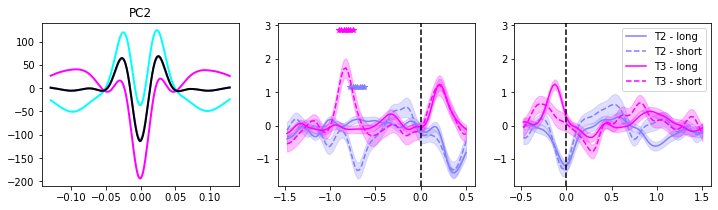

stat_fun(H1): min=-3.387048 max=1.079588
Running initial clustering …
Using 678 thresholds from 0.00 to 3.39 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.411203 max=2.130419
Running initial clustering …
Using 483 thresholds from 0.00 to 2.41 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-4.179210 max=2.536376
Running initial clustering …
Using 836 thresholds from 0.00 to 4.17 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.057337 max=5.589077
Running initial clustering …
Using 1118 thresholds from 0.00 to 5.58 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.962842 max=4.708949
Running initial clustering …
Using 942 thresholds from 0.00 to 4.71 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

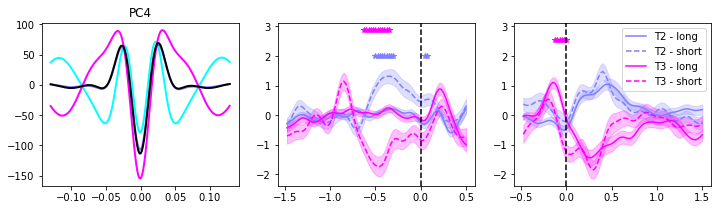

stat_fun(H1): min=-2.086007 max=1.943331
Running initial clustering …
Using 418 thresholds from 0.00 to 2.08 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.038222 max=1.600691
Running initial clustering …
Using 408 thresholds from 0.00 to 2.04 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.898393 max=2.880908
Running initial clustering …
Using 577 thresholds from 0.00 to 2.88 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.445227 max=3.583352
Running initial clustering …
Using 717 thresholds from 0.00 to 3.58 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.920571 max=2.375936
Running initial clustering …
Using 476 thresholds from 0.00 to 2.38 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

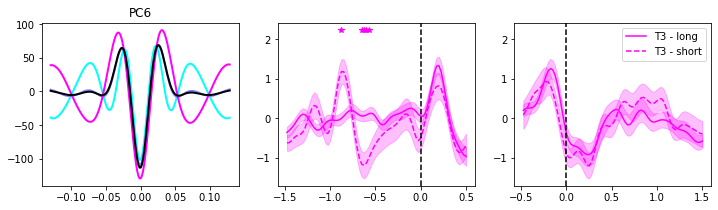

stat_fun(H1): min=-2.972138 max=5.299271
Running initial clustering …
Using 1060 thresholds from 0.00 to 5.29 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.372732 max=4.069261
Running initial clustering …
Using 814 thresholds from 0.00 to 4.07 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.553258 max=1.741511
Running initial clustering …
Using 711 thresholds from 0.00 to 3.55 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.601290 max=2.405199
Running initial clustering …
Using 721 thresholds from 0.00 to 3.60 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-5.522995 max=2.380363
Running initial clustering …
Using 1105 thresholds from 0.00 to 5.52 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

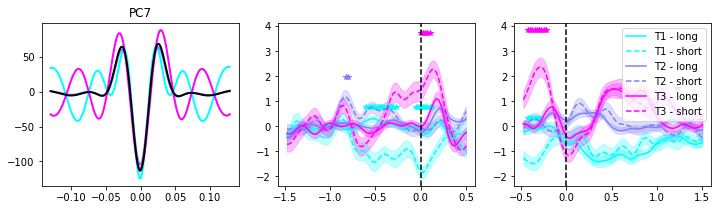

stat_fun(H1): min=-3.076850 max=3.300792
Running initial clustering …
Using 661 thresholds from 0.00 to 3.30 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.085863 max=2.615020
Running initial clustering …
Using 524 thresholds from 0.00 to 2.62 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.596327 max=1.644912
Running initial clustering …
Using 720 thresholds from 0.00 to 3.60 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.337672 max=7.250191
Running initial clustering …
Using 1451 thresholds from 0.00 to 7.25 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.191304 max=3.747124
Running initial clustering …
Using 750 thresholds from 0.00 to 3.75 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

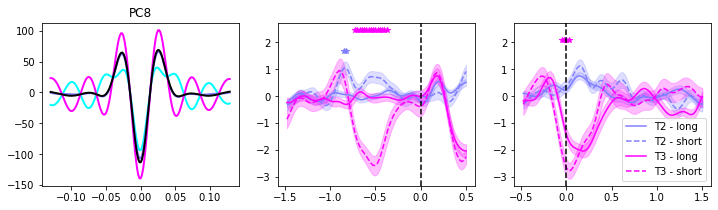

stat_fun(H1): min=-4.085359 max=1.510720
Running initial clustering …
Using 818 thresholds from 0.00 to 4.08 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.267310 max=1.058790
Running initial clustering …
Using 454 thresholds from 0.00 to 2.27 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.549650 max=0.921533
Running initial clustering …
Using 510 thresholds from 0.00 to 2.54 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.725536 max=6.254163
Running initial clustering …
Using 1251 thresholds from 0.00 to 6.25 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.300181 max=3.429189
Running initial clustering …
Using 686 thresholds from 0.00 to 3.43 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

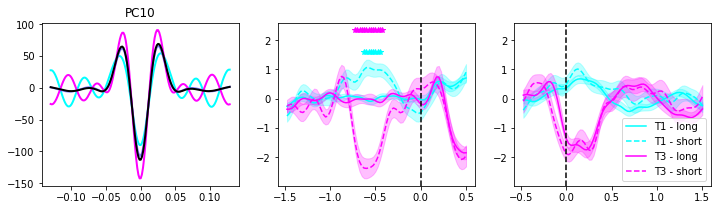

stat_fun(H1): min=-3.189327 max=1.541975
Running initial clustering …
Using 638 thresholds from 0.00 to 3.19 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.411917 max=1.229305
Running initial clustering …
Using 483 thresholds from 0.00 to 2.41 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-4.357417 max=1.641637
Running initial clustering …
Using 872 thresholds from 0.00 to 4.36 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.893156 max=5.132332
Running initial clustering …
Using 1027 thresholds from 0.00 to 5.13 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.103625 max=2.461079
Running initial clustering …
Using 621 thresholds from 0.00 to 3.10 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

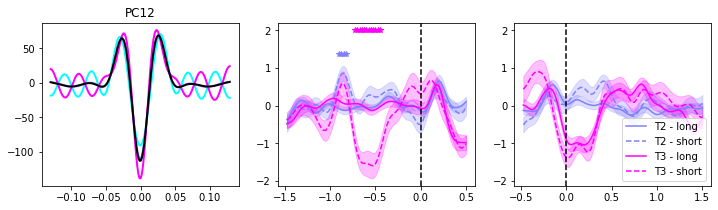

In [24]:
## TD only
step = 100 / n_q

# Define custom paired t-test function (returns t-values only, no p-values)
def ttest_rel_no_p(x, y, axis=0):
    tvals, _ = stats.ttest_rel(x, y, axis=axis, nan_policy='omit')
    return tvals

paired_t = partial(ttest_rel_no_p, axis=0)
threshold_tfce = dict(start=0, step=0.005)


for pc in task_pcs:
    q_bins = np.percentile(pc_scores[:, pc], np.arange(0, 100 + step, step))

    q_rates_smoothed = {q: {epoch_type: {condition: [] for condition in condition_names} for epoch_type in epoch_types} for q in range(n_q)}
    for subject_id in subject_ids:
        subj_idx = (all_bursts['subject_id'] == subject_id)

        subject_group=groups[subject_id].strip()
        if subject_group=='TD':
            long_stim_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & stim_idx & (all_bursts['condition']=='LONG')
            short_stim_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & stim_idx & (all_bursts['condition']=='SHORT')
            long_resp_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & resp_idx & (all_bursts['condition']=='LONG')
            short_resp_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & resp_idx & (all_bursts['condition']=='SHORT')

            for q in range(n_q):
                q_idx = ((pc_scores[:, pc] >= q_bins[q]) &
                         (pc_scores[:, pc] <= q_bins[q+1]))
                long_stim_trials = np.unique(all_bursts['trial'][long_stim_b_idx])
                short_stim_trials = np.unique(all_bursts['trial'][short_stim_b_idx])
                long_resp_trials = np.unique(all_bursts['trial'][long_resp_b_idx])
                short_resp_trials = np.unique(all_bursts['trial'][short_resp_b_idx])

                long_stim_unsmoothed_rate, _ = np.histogram(
                    all_bursts['peak_time'][subj_idx & long_stim_b_idx & q_idx],
                    bins=stim_time_bins
                )
                short_stim_unsmoothed_rate, _ = np.histogram(
                    all_bursts['peak_time'][subj_idx & short_stim_b_idx & q_idx],
                    bins=stim_time_bins
                )
                long_resp_unsmoothed_rate, _ = np.histogram(
                    all_bursts['peak_time'][subj_idx & long_resp_b_idx & q_idx],
                    bins=resp_time_bins
                )
                short_resp_unsmoothed_rate, _ = np.histogram(
                    all_bursts['peak_time'][subj_idx & short_resp_b_idx & q_idx],
                    bins=resp_time_bins
                )

                # Convert to rate
                long_stim_unsmoothed_rate = (long_stim_unsmoothed_rate / bin_width) / len(long_stim_trials)
                short_stim_unsmoothed_rate = (short_stim_unsmoothed_rate / bin_width) / len(short_stim_trials)
                long_resp_unsmoothed_rate = (long_resp_unsmoothed_rate / bin_width) / len(long_resp_trials)
                short_resp_unsmoothed_rate = (short_resp_unsmoothed_rate / bin_width) / len(short_resp_trials)

                long_stim_smoothed_rate = gaussian_filter1d(long_stim_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
                short_stim_smoothed_rate = gaussian_filter1d(short_stim_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
                long_resp_smoothed_rate = gaussian_filter1d(long_resp_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
                short_resp_smoothed_rate = gaussian_filter1d(short_resp_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")

                base_idx = np.where((stim_time_bins < -0.1))[0]
                base_rate = np.mean(long_stim_smoothed_rate[base_idx])
#                 if base_rate>0:
#                     long_stim_smoothed_rate = (long_stim_smoothed_rate - base_rate)/base_rate*100
#                     short_stim_smoothed_rate = (short_stim_smoothed_rate - base_rate)/base_rate*100
#                     long_resp_smoothed_rate = (long_resp_smoothed_rate - base_rate)/base_rate*100
#                     short_resp_smoothed_rate = (short_resp_smoothed_rate - base_rate)/base_rate*100

#                     q_rates_smoothed[q]['STIM']['LONG'].append(long_stim_smoothed_rate)
#                     q_rates_smoothed[q]['STIM']['SHORT'].append(short_stim_smoothed_rate)
#                     q_rates_smoothed[q]['RESP']['LONG'].append(long_resp_smoothed_rate)
#                     q_rates_smoothed[q]['RESP']['SHORT'].append(short_resp_smoothed_rate)
                long_stim_smoothed_rate = (long_stim_smoothed_rate - base_rate)[stim_plt_idx]
                short_stim_smoothed_rate = (short_stim_smoothed_rate - base_rate)[stim_plt_idx]
                long_resp_smoothed_rate = (long_resp_smoothed_rate - base_rate)[resp_plt_idx]
                short_resp_smoothed_rate = (short_resp_smoothed_rate - base_rate)[resp_plt_idx]

                q_rates_smoothed[q]['STIM']['LONG'].append(long_stim_smoothed_rate)
                q_rates_smoothed[q]['STIM']['SHORT'].append(short_stim_smoothed_rate)
                q_rates_smoothed[q]['RESP']['LONG'].append(long_resp_smoothed_rate)
                q_rates_smoothed[q]['RESP']['SHORT'].append(short_resp_smoothed_rate)
            
    plt.figure(figsize=(12,3))

    ax=plt.subplot(1,3,1)
    ax.set_title(f'PC{pc+1}')  # set the nice title
    scores = pc_scores[:,pc]
    q_maps = []
    for q_ix, (b, e) in enumerate(quartiles):
        q_map = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))  # create a boolean map to select the waveforms
        q_mean = np.mean(waveforms[q_map], axis=0)
        ax.plot(waveform_times, q_mean/1e-15, lw=2, c=col_range[q_ix], label="Q {}".format(q_ix+1))
    ax.plot(waveform_times, mean_waveform/1e-15, lw=2, c="black", label="mean")

    # STIM
    ax1 = plt.subplot(1,3,2)
    # RESP
    ax2 = plt.subplot(1,3,3)    
    
    for q in range(n_q):
        stim_data = [np.array(q_rates_smoothed[q]['STIM']['LONG']), np.array(q_rates_smoothed[q]['STIM']['SHORT'])]
        stim_T_obs, stim_clusters, stim_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            stim_data,
            stat_fun=paired_t,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        resp_data = [np.array(q_rates_smoothed[q]['RESP']['LONG']), np.array(q_rates_smoothed[q]['RESP']['SHORT'])]
        resp_T_obs, resp_clusters, resp_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            resp_data,
            stat_fun=paired_t,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        
        if len(np.where(stim_cluster_p_values<0.05)[0])>1 or len(np.where(resp_cluster_p_values<0.05)[0])>1:
            m_rate=np.mean(q_rates_smoothed[q]['STIM']['LONG'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['STIM']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['STIM']['LONG']))
            ax1.plot(stim_time_plt, m_rate, color=col_range[q])
            ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            m_rate=np.mean(q_rates_smoothed[q]['STIM']['SHORT'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['STIM']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['STIM']['SHORT']))
            ax1.plot(stim_time_plt, m_rate, '--', color=col_range[q])
            ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            # Plot significant clusters
            yl = ax1.get_ylim()
            py = yl[1] + (q+1)*.1 * (yl[1] - 0)
            for p_idx, p_val in enumerate(stim_cluster_p_values):
                if p_val < 0.05:
                    ax1.plot(stim_time_plt[p_idx], py, '*', color=col_range[q])
                    
            
            m_rate=np.mean(q_rates_smoothed[q]['RESP']['LONG'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['RESP']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['RESP']['LONG']))
            ax2.plot(resp_time_plt, m_rate, color=col_range[q], label=f'T{q+1} - long')
            ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            m_rate=np.mean(q_rates_smoothed[q]['RESP']['SHORT'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['RESP']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['RESP']['SHORT']))
            ax2.plot(resp_time_plt, m_rate, '--', color=col_range[q], label=f'T{q+1} - short')
            ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            ax2.legend()
            # Plot significant clusters
            yl = ax2.get_ylim()
            py = yl[1] + (q+1)*.1 * (yl[1] - 0)
            for p_idx, p_val in enumerate(resp_cluster_p_values):
                if p_val < 0.05:
                    ax2.plot(resp_time_plt[p_idx], py, '*', color=col_range[q])
                    
    ax1.axvline(0,color='k',linestyle='--')
    yl1=ax1.get_ylim()

    ax2.axvline(0,color='k',linestyle='--')
    yl2=ax2.get_ylim()

    ymin=np.min([yl1[0], yl2[0]])
    ymax=np.max([yl1[1], yl2[1]])
    ax1.set_ylim(ymin, ymax)
    ax2.set_ylim(ymin, ymax)
    plt.show()

stat_fun(H1): min=-1.467932 max=3.417423
Running initial clustering …
Using 684 thresholds from 0.00 to 3.42 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.308082 max=1.795846
Running initial clustering …
Using 462 thresholds from 0.00 to 2.31 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.360907 max=4.173376
Running initial clustering …
Using 835 thresholds from 0.00 to 4.17 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.911814 max=2.690019
Running initial clustering …
Using 783 thresholds from 0.00 to 3.91 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.963710 max=2.903951
Running initial clustering …
Using 581 thresholds from 0.00 to 2.90 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

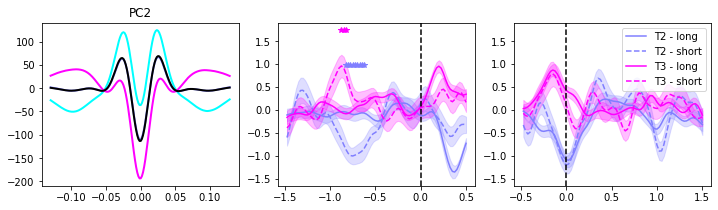

stat_fun(H1): min=-3.696313 max=2.114634
Running initial clustering …
Using 740 thresholds from 0.00 to 3.70 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.141396 max=1.524292
Running initial clustering …
Using 429 thresholds from 0.00 to 2.14 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.352161 max=1.527840
Running initial clustering …
Using 671 thresholds from 0.00 to 3.35 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.643380 max=4.794152
Running initial clustering …
Using 959 thresholds from 0.00 to 4.79 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.017859 max=2.260293
Running initial clustering …
Using 453 thresholds from 0.00 to 2.26 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

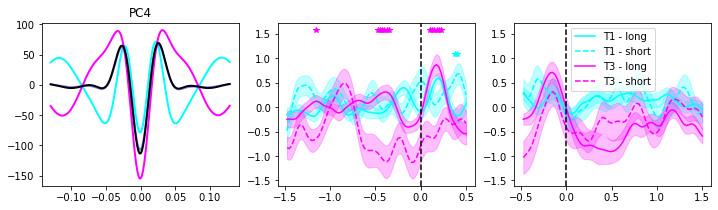

stat_fun(H1): min=-2.119728 max=2.559428
Running initial clustering …
Using 512 thresholds from 0.00 to 2.56 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.745026 max=2.494432
Running initial clustering …
Using 499 thresholds from 0.00 to 2.49 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.778419 max=1.764822
Running initial clustering …
Using 756 thresholds from 0.00 to 3.77 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.933064 max=3.769727
Running initial clustering …
Using 754 thresholds from 0.00 to 3.77 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.097687 max=2.108130
Running initial clustering …
Using 422 thresholds from 0.00 to 2.10 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

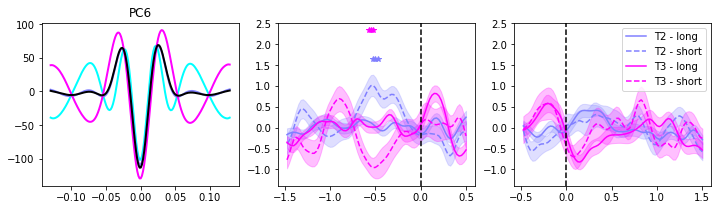

stat_fun(H1): min=-2.433167 max=3.430345
Running initial clustering …
Using 687 thresholds from 0.00 to 3.43 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.947284 max=3.250888
Running initial clustering …
Using 651 thresholds from 0.00 to 3.25 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.946553 max=2.647552
Running initial clustering …
Using 530 thresholds from 0.00 to 2.65 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.159500 max=1.009683
Running initial clustering …
Using 632 thresholds from 0.00 to 3.16 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.384081 max=1.164007
Running initial clustering …
Using 477 thresholds from 0.00 to 2.38 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

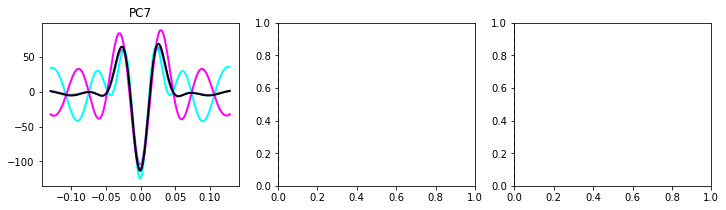

stat_fun(H1): min=-2.646859 max=1.562259
Running initial clustering …
Using 530 thresholds from 0.00 to 2.65 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.610698 max=2.331591
Running initial clustering …
Using 523 thresholds from 0.00 to 2.61 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.488352 max=1.670950
Running initial clustering …
Using 498 thresholds from 0.00 to 2.48 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-0.650377 max=3.997914
Running initial clustering …
Using 800 thresholds from 0.00 to 4.00 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-3.333183 max=2.327415
Running initial clustering …
Using 667 thresholds from 0.00 to 3.33 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

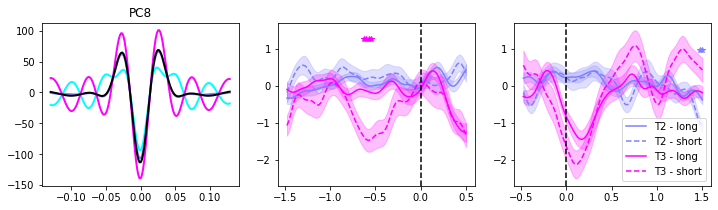

stat_fun(H1): min=-2.489829 max=3.140956
Running initial clustering …
Using 629 thresholds from 0.00 to 3.14 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.697839 max=2.018597
Running initial clustering …
Using 540 thresholds from 0.00 to 2.69 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.196911 max=1.802842
Running initial clustering …
Using 440 thresholds from 0.00 to 2.19 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.101029 max=4.695776
Running initial clustering …
Using 940 thresholds from 0.00 to 4.70 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.483917 max=2.855414
Running initial clustering …
Using 572 thresholds from 0.00 to 2.85 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

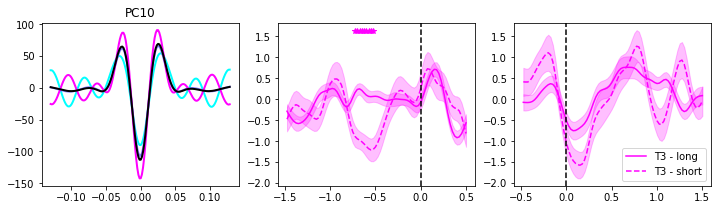

stat_fun(H1): min=-2.374003 max=2.887837
Running initial clustering …
Using 578 thresholds from 0.00 to 2.89 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.859509 max=1.212703
Running initial clustering …
Using 572 thresholds from 0.00 to 2.85 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-2.900654 max=2.598254
Running initial clustering …
Using 581 thresholds from 0.00 to 2.90 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.529348 max=4.281031
Running initial clustering …
Using 857 thresholds from 0.00 to 4.28 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=-1.666947 max=1.195435
Running initial clustering …
Using 334 thresholds from 0.00 to 1.67 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

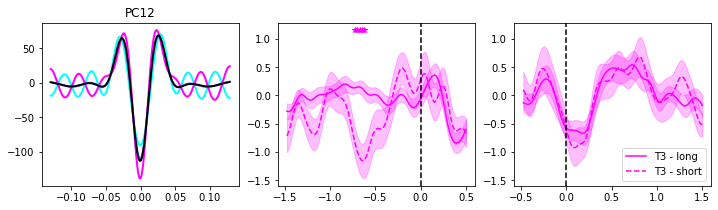

In [25]:
## ASD only
step = 100 / n_q

# Define custom paired t-test function (returns t-values only, no p-values)
def ttest_rel_no_p(x, y, axis=0):
    tvals, _ = stats.ttest_rel(x, y, axis=axis, nan_policy='omit')
    return tvals

paired_t = partial(ttest_rel_no_p, axis=0)
threshold_tfce = dict(start=0, step=0.005)


for pc in task_pcs:
    q_bins = np.percentile(pc_scores[:, pc], np.arange(0, 100 + step, step))

    q_rates_smoothed = {q: {epoch_type: {condition: [] for condition in condition_names} for epoch_type in epoch_types} for q in range(n_q)}
    for subject_id in subject_ids:
        subj_idx = (all_bursts['subject_id'] == subject_id)

        subject_group=groups[subject_id].strip()
        if subject_group=='ASD':
            long_stim_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & stim_idx & (all_bursts['condition']=='LONG')
            short_stim_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & stim_idx & (all_bursts['condition']=='SHORT')
            long_resp_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & resp_idx & (all_bursts['condition']=='LONG')
            short_resp_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & resp_idx & (all_bursts['condition']=='SHORT')

            for q in range(n_q):
                q_idx = ((pc_scores[:, pc] >= q_bins[q]) &
                         (pc_scores[:, pc] <= q_bins[q+1]))
                long_stim_trials = np.unique(all_bursts['trial'][long_stim_b_idx])
                short_stim_trials = np.unique(all_bursts['trial'][short_stim_b_idx])
                long_resp_trials = np.unique(all_bursts['trial'][long_resp_b_idx])
                short_resp_trials = np.unique(all_bursts['trial'][short_resp_b_idx])

                long_stim_unsmoothed_rate, _ = np.histogram(
                    all_bursts['peak_time'][subj_idx & long_stim_b_idx & q_idx],
                    bins=stim_time_bins
                )
                short_stim_unsmoothed_rate, _ = np.histogram(
                    all_bursts['peak_time'][subj_idx & short_stim_b_idx & q_idx],
                    bins=stim_time_bins
                )
                long_resp_unsmoothed_rate, _ = np.histogram(
                    all_bursts['peak_time'][subj_idx & long_resp_b_idx & q_idx],
                    bins=resp_time_bins
                )
                short_resp_unsmoothed_rate, _ = np.histogram(
                    all_bursts['peak_time'][subj_idx & short_resp_b_idx & q_idx],
                    bins=resp_time_bins
                )

                # Convert to rate
                long_stim_unsmoothed_rate = (long_stim_unsmoothed_rate / bin_width) / len(long_stim_trials)
                short_stim_unsmoothed_rate = (short_stim_unsmoothed_rate / bin_width) / len(short_stim_trials)
                long_resp_unsmoothed_rate = (long_resp_unsmoothed_rate / bin_width) / len(long_resp_trials)
                short_resp_unsmoothed_rate = (short_resp_unsmoothed_rate / bin_width) / len(short_resp_trials)

                long_stim_smoothed_rate = gaussian_filter1d(long_stim_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
                short_stim_smoothed_rate = gaussian_filter1d(short_stim_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
                long_resp_smoothed_rate = gaussian_filter1d(long_resp_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
                short_resp_smoothed_rate = gaussian_filter1d(short_resp_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")

                base_idx = np.where((stim_time_bins < -0.1))[0]
                base_rate = np.mean(long_stim_smoothed_rate[base_idx])
#                 if base_rate>0:
#                     long_stim_smoothed_rate = (long_stim_smoothed_rate - base_rate)/base_rate*100
#                     short_stim_smoothed_rate = (short_stim_smoothed_rate - base_rate)/base_rate*100
#                     long_resp_smoothed_rate = (long_resp_smoothed_rate - base_rate)/base_rate*100
#                     short_resp_smoothed_rate = (short_resp_smoothed_rate - base_rate)/base_rate*100

#                     q_rates_smoothed[q]['STIM']['LONG'].append(long_stim_smoothed_rate)
#                     q_rates_smoothed[q]['STIM']['SHORT'].append(short_stim_smoothed_rate)
#                     q_rates_smoothed[q]['RESP']['LONG'].append(long_resp_smoothed_rate)
#                     q_rates_smoothed[q]['RESP']['SHORT'].append(short_resp_smoothed_rate)
                long_stim_smoothed_rate = (long_stim_smoothed_rate - base_rate)[stim_plt_idx]
                short_stim_smoothed_rate = (short_stim_smoothed_rate - base_rate)[stim_plt_idx]
                long_resp_smoothed_rate = (long_resp_smoothed_rate - base_rate)[resp_plt_idx]
                short_resp_smoothed_rate = (short_resp_smoothed_rate - base_rate)[resp_plt_idx]

                q_rates_smoothed[q]['STIM']['LONG'].append(long_stim_smoothed_rate)
                q_rates_smoothed[q]['STIM']['SHORT'].append(short_stim_smoothed_rate)
                q_rates_smoothed[q]['RESP']['LONG'].append(long_resp_smoothed_rate)
                q_rates_smoothed[q]['RESP']['SHORT'].append(short_resp_smoothed_rate)
            
    plt.figure(figsize=(12,3))

    ax=plt.subplot(1,3,1)
    ax.set_title(f'PC{pc+1}')  # set the nice title
    scores = pc_scores[:,pc]
    q_maps = []
    for q_ix, (b, e) in enumerate(quartiles):
        q_map = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))  # create a boolean map to select the waveforms
        q_mean = np.mean(waveforms[q_map], axis=0)
        ax.plot(waveform_times, q_mean/1e-15, lw=2, c=col_range[q_ix], label="Q {}".format(q_ix+1))
    ax.plot(waveform_times, mean_waveform/1e-15, lw=2, c="black", label="mean")

    # STIM
    ax1 = plt.subplot(1,3,2)
    # RESP
    ax2 = plt.subplot(1,3,3)    
    
    for q in range(n_q):
        stim_data = [np.array(q_rates_smoothed[q]['STIM']['LONG']), np.array(q_rates_smoothed[q]['STIM']['SHORT'])]
        stim_T_obs, stim_clusters, stim_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            stim_data,
            stat_fun=paired_t,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        resp_data = [np.array(q_rates_smoothed[q]['RESP']['LONG']), np.array(q_rates_smoothed[q]['RESP']['SHORT'])]
        resp_T_obs, resp_clusters, resp_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            resp_data,
            stat_fun=paired_t,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        
        if len(np.where(stim_cluster_p_values<0.05)[0])>1 or len(np.where(resp_cluster_p_values<0.05)[0])>1:
            m_rate=np.mean(q_rates_smoothed[q]['STIM']['LONG'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['STIM']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['STIM']['LONG']))
            ax1.plot(stim_time_plt, m_rate, color=col_range[q])
            ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            m_rate=np.mean(q_rates_smoothed[q]['STIM']['SHORT'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['STIM']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['STIM']['SHORT']))
            ax1.plot(stim_time_plt, m_rate, '--', color=col_range[q])
            ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            # Plot significant clusters
            yl = ax1.get_ylim()
            py = yl[1] + (q+1)*.1 * (yl[1] - 0)
            for p_idx, p_val in enumerate(stim_cluster_p_values):
                if p_val < 0.05:
                    ax1.plot(stim_time_plt[p_idx], py, '*', color=col_range[q])
                    
            
            m_rate=np.mean(q_rates_smoothed[q]['RESP']['LONG'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['RESP']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['RESP']['LONG']))
            ax2.plot(resp_time_plt, m_rate, color=col_range[q], label=f'T{q+1} - long')
            ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            m_rate=np.mean(q_rates_smoothed[q]['RESP']['SHORT'],axis=0)
            se_rate=np.std(q_rates_smoothed[q]['RESP']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed[q]['RESP']['SHORT']))
            ax2.plot(resp_time_plt, m_rate, '--', color=col_range[q], label=f'T{q+1} - short')
            ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            ax2.legend()
            # Plot significant clusters
            yl = ax2.get_ylim()
            py = yl[1] + (q+1)*.1 * (yl[1] - 0)
            for p_idx, p_val in enumerate(resp_cluster_p_values):
                if p_val < 0.05:
                    ax2.plot(resp_time_plt[p_idx], py, '*', color=col_range[q])
                    
    ax1.axvline(0,color='k',linestyle='--')
    yl1=ax1.get_ylim()

    ax2.axvline(0,color='k',linestyle='--')
    yl2=ax2.get_ylim()

    ymin=np.min([yl1[0], yl2[0]])
    ymax=np.max([yl1[1], yl2[1]])
    ax1.set_ylim(ymin, ymax)
    ax2.set_ylim(ymin, ymax)
    plt.show()

stat_fun(H1): min=0.000000 max=3.824483
Running initial clustering …
Using 765 thresholds from 0.00 to 3.82 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000366 max=6.471726
Running initial clustering …
Using 1295 thresholds from 0.00 to 6.47 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000193 max=4.570646
Running initial clustering …
Using 915 thresholds from 0.00 to 4.57 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000030 max=6.762512
Running initial clustering …
Using 1353 thresholds from 0.00 to 6.76 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000002 max=13.870603
Running initial clustering …
Using 2775 thresholds from 0.00 to 13.87 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

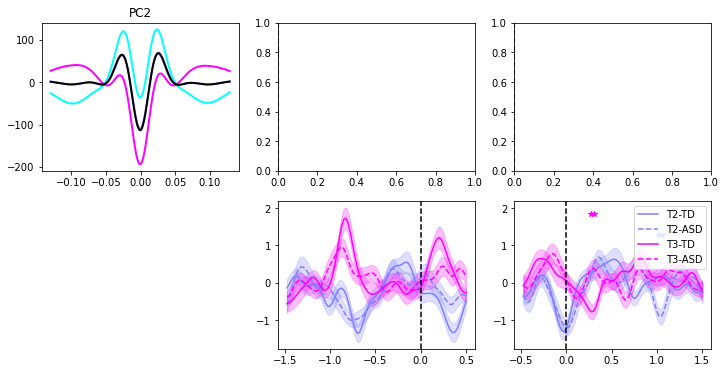

stat_fun(H1): min=0.000712 max=4.050247
Running initial clustering …
Using 811 thresholds from 0.00 to 4.05 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000008 max=4.757018
Running initial clustering …
Using 952 thresholds from 0.00 to 4.75 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.001127 max=2.849256
Running initial clustering …
Using 570 thresholds from 0.00 to 2.85 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000002 max=4.293087
Running initial clustering …
Using 859 thresholds from 0.00 to 4.29 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000769 max=11.777540
Running initial clustering …
Using 2356 thresholds from 0.00 to 11.78 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

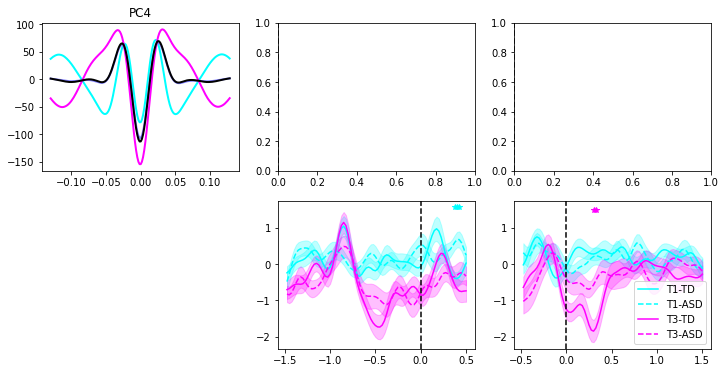

stat_fun(H1): min=0.000755 max=3.530156
Running initial clustering …
Using 707 thresholds from 0.00 to 3.53 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.001570 max=4.008456
Running initial clustering …
Using 802 thresholds from 0.00 to 4.00 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000286 max=3.413977
Running initial clustering …
Using 683 thresholds from 0.00 to 3.41 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000617 max=6.339996
Running initial clustering …
Using 1268 thresholds from 0.00 to 6.33 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000004 max=5.447196
Running initial clustering …
Using 1090 thresholds from 0.00 to 5.45 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

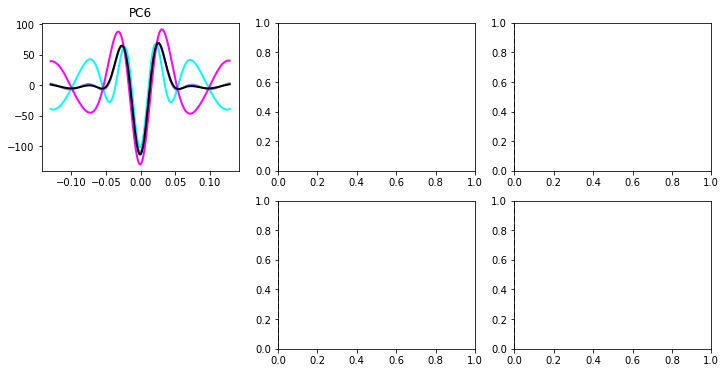

stat_fun(H1): min=0.000179 max=3.147631
Running initial clustering …
Using 630 thresholds from 0.00 to 3.15 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.001075 max=8.614159
Running initial clustering …
Using 1723 thresholds from 0.00 to 8.61 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000677 max=3.595481
Running initial clustering …
Using 720 thresholds from 0.00 to 3.60 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.001448 max=6.978753
Running initial clustering …
Using 1396 thresholds from 0.00 to 6.98 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000750 max=6.894314
Running initial clustering …
Using 1379 thresholds from 0.00 to 6.89 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

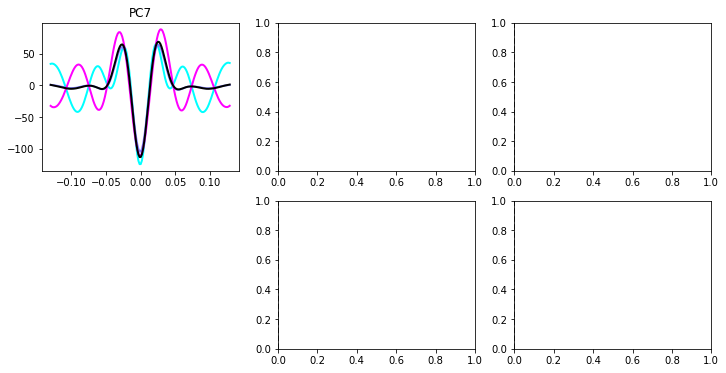

stat_fun(H1): min=0.000035 max=3.244224
Running initial clustering …
Using 649 thresholds from 0.00 to 3.24 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000476 max=3.209246
Running initial clustering …
Using 642 thresholds from 0.00 to 3.21 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000392 max=4.353888
Running initial clustering …
Using 871 thresholds from 0.00 to 4.35 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000949 max=8.988187
Running initial clustering …
Using 1798 thresholds from 0.00 to 8.98 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.002141 max=6.958755
Running initial clustering …
Using 1392 thresholds from 0.00 to 6.96 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

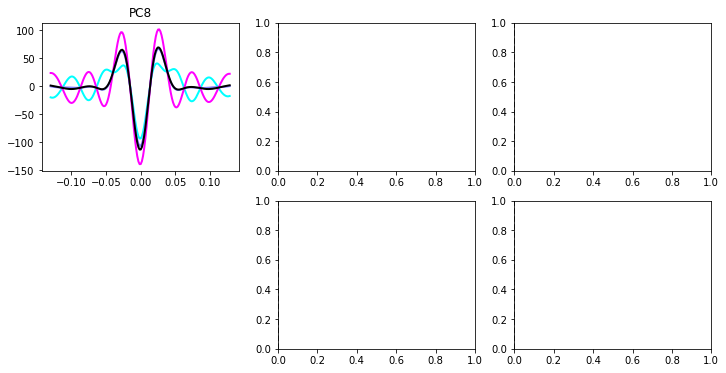

stat_fun(H1): min=0.000018 max=10.301651
Running initial clustering …
Using 2061 thresholds from 0.00 to 10.30 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000181 max=14.032478
Running initial clustering …
Using 2807 thresholds from 0.00 to 14.03 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000049 max=2.767720
Running initial clustering …
Using 554 thresholds from 0.00 to 2.77 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.003334 max=14.398043
Running initial clustering …
Using 2880 thresholds from 0.00 to 14.39 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000126 max=8.547875
Running initial clustering …
Using 1710 thresholds from 0.00 to 8.54 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

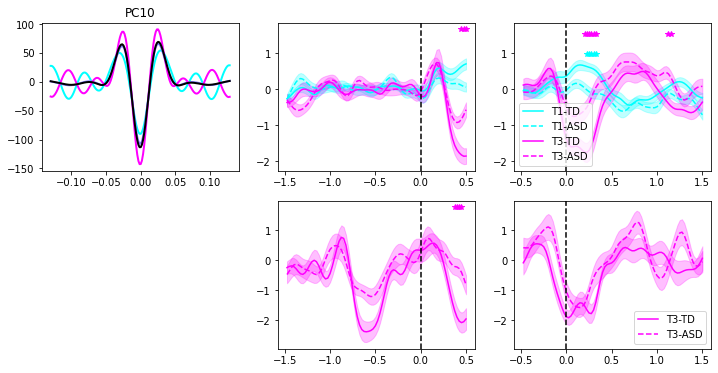

stat_fun(H1): min=0.000189 max=7.436816
Running initial clustering …
Using 1488 thresholds from 0.00 to 7.44 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000005 max=1.650258
Running initial clustering …
Using 331 thresholds from 0.00 to 1.65 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000483 max=4.628187
Running initial clustering …
Using 926 thresholds from 0.00 to 4.62 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


...

  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.003564 max=4.044691
Running initial clustering …
Using 809 thresholds from 0.00 to 4.04 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

stat_fun(H1): min=0.000171 max=5.679726
Running initial clustering …
Using 1136 thresholds from 0.00 to 5.67 for TFCE computation (h_power=2.00, e_power=0.50)
Found 80 clusters


  0%|          | Permuting : 0/999 [00:00<?,       ?it/s]

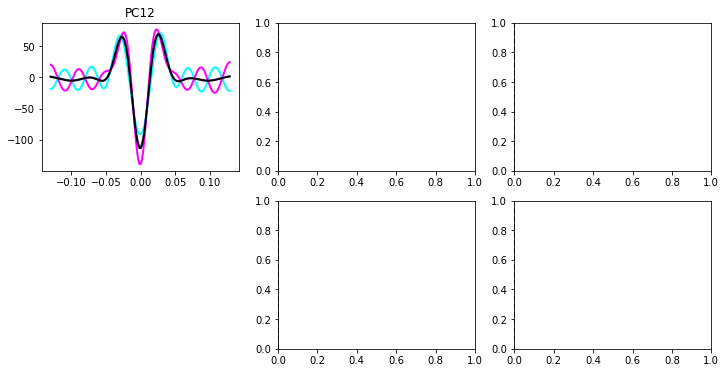

In [26]:
step = 100 / n_q

threshold_tfce = dict(start=0, step=0.005)

for pc in task_pcs:
    q_bins = np.percentile(pc_scores[:, pc], np.arange(0, 100 + step, step))

    q_rates_smoothed = {
        group: {
            q: {
                epoch_type: {
                    condition: [] for condition in condition_names
                } for epoch_type in epoch_types
            } for q in range(n_q)
        } for group in ['ASD','TD']
    }
    for subject_id in subject_ids:
        subj_idx = (all_bursts['subject_id'] == subject_id)

        subject_group=groups[subject_id].strip()

        long_stim_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & stim_idx & (all_bursts['condition']=='LONG')
        short_stim_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & stim_idx & (all_bursts['condition']=='SHORT')
        long_resp_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & resp_idx & (all_bursts['condition']=='LONG')
        short_resp_b_idx=hemi_idx & (all_bursts['subject_id']==subject_id) & resp_idx & (all_bursts['condition']=='SHORT')

        for q in range(n_q):
            q_idx = ((pc_scores[:, pc] >= q_bins[q]) &
                     (pc_scores[:, pc] <= q_bins[q+1]))
            long_stim_trials = np.unique(all_bursts['trial'][long_stim_b_idx])
            short_stim_trials = np.unique(all_bursts['trial'][short_stim_b_idx])
            long_resp_trials = np.unique(all_bursts['trial'][long_resp_b_idx])
            short_resp_trials = np.unique(all_bursts['trial'][short_resp_b_idx])

            long_stim_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & long_stim_b_idx & q_idx],
                bins=stim_time_bins
            )
            short_stim_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & short_stim_b_idx & q_idx],
                bins=stim_time_bins
            )
            long_resp_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & long_resp_b_idx & q_idx],
                bins=resp_time_bins
            )
            short_resp_unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & short_resp_b_idx & q_idx],
                bins=resp_time_bins
            )

            # Convert to rate
            long_stim_unsmoothed_rate = (long_stim_unsmoothed_rate / bin_width) / len(long_stim_trials)
            short_stim_unsmoothed_rate = (short_stim_unsmoothed_rate / bin_width) / len(short_stim_trials)
            long_resp_unsmoothed_rate = (long_resp_unsmoothed_rate / bin_width) / len(long_resp_trials)
            short_resp_unsmoothed_rate = (short_resp_unsmoothed_rate / bin_width) / len(short_resp_trials)

            long_stim_smoothed_rate = gaussian_filter1d(long_stim_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            short_stim_smoothed_rate = gaussian_filter1d(short_stim_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            long_resp_smoothed_rate = gaussian_filter1d(long_resp_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")
            short_resp_smoothed_rate = gaussian_filter1d(short_resp_unsmoothed_rate, sigma=2.5, axis=0, mode="nearest")

            base_idx = np.where((stim_time_bins < -0.1))[0]
            base_rate = np.mean(long_stim_smoothed_rate[base_idx])
#             if base_rate>0:
#                 long_stim_smoothed_rate = (long_stim_smoothed_rate - base_rate)/base_rate*100
#                 short_stim_smoothed_rate = (short_stim_smoothed_rate - base_rate)/base_rate*100
#                 long_resp_smoothed_rate = (long_resp_smoothed_rate - base_rate)/base_rate*100
#                 short_resp_smoothed_rate = (short_resp_smoothed_rate - base_rate)/base_rate*100

#                 q_rates_smoothed[subject_group][q]['STIM']['LONG'].append(long_stim_smoothed_rate)
#                 q_rates_smoothed[subject_group][q]['STIM']['SHORT'].append(short_stim_smoothed_rate)
#                 q_rates_smoothed[subject_group][q]['RESP']['LONG'].append(long_resp_smoothed_rate)
#                 q_rates_smoothed[subject_group][q]['RESP']['SHORT'].append(short_resp_smoothed_rate)
            long_stim_smoothed_rate = (long_stim_smoothed_rate - base_rate)[stim_plt_idx]
            short_stim_smoothed_rate = (short_stim_smoothed_rate - base_rate)[stim_plt_idx]
            long_resp_smoothed_rate = (long_resp_smoothed_rate - base_rate)[resp_plt_idx]
            short_resp_smoothed_rate = (short_resp_smoothed_rate - base_rate)[resp_plt_idx]

            q_rates_smoothed[subject_group][q]['STIM']['LONG'].append(long_stim_smoothed_rate)
            q_rates_smoothed[subject_group][q]['STIM']['SHORT'].append(short_stim_smoothed_rate)
            q_rates_smoothed[subject_group][q]['RESP']['LONG'].append(long_resp_smoothed_rate)
            q_rates_smoothed[subject_group][q]['RESP']['SHORT'].append(short_resp_smoothed_rate)
            
    plt.figure(figsize=(12,6))

    ax=plt.subplot(2,3,1)
    ax.set_title(f'PC{pc+1}')  # set the nice title
    scores = pc_scores[:,pc]
    q_maps = []
    for q_ix, (b, e) in enumerate(quartiles):
        q_map = (scores > np.percentile(scores, b)) & (scores <= np.percentile(scores, e))  # create a boolean map to select the waveforms
        q_mean = np.mean(waveforms[q_map], axis=0)
        ax.plot(waveform_times, q_mean/1e-15, lw=2, c=col_range[q_ix], label="Q {}".format(q_ix+1))
    ax.plot(waveform_times, mean_waveform/1e-15, lw=2, c="black", label="mean")

    # STIM
    ax1 = plt.subplot(2,3,2)
    # RESP
    ax2 = plt.subplot(2,3,3)
    for q in range(n_q):
        stim_data = [np.array(q_rates_smoothed['TD'][q]['STIM']['LONG']), np.array(q_rates_smoothed['ASD'][q]['STIM']['LONG'])]
        stim_T_obs, stim_clusters, stim_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            stim_data,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        resp_data = [np.array(q_rates_smoothed['TD'][q]['RESP']['LONG']), np.array(q_rates_smoothed['ASD'][q]['RESP']['LONG'])]
        resp_T_obs, resp_clusters, resp_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            resp_data,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        
        if len(np.where(stim_cluster_p_values<0.05)[0])>1 or len(np.where(resp_cluster_p_values<0.05)[0])>1:
            m_rate=np.mean(q_rates_smoothed['TD'][q]['STIM']['LONG'],axis=0)
            se_rate=np.std(q_rates_smoothed['TD'][q]['STIM']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed['TD'][q]['STIM']['LONG']))
            ax1.plot(stim_time_plt, m_rate, color=col_range[q])
            ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            m_rate=np.mean(q_rates_smoothed['ASD'][q]['STIM']['LONG'],axis=0)
            se_rate=np.std(q_rates_smoothed['ASD'][q]['STIM']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed['ASD'][q]['STIM']['LONG']))
            ax1.plot(stim_time_plt, m_rate, '--', color=col_range[q])
            ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            # Plot significant clusters
            yl = ax1.get_ylim()
            py = yl[1] + (q+1)*.1 * (yl[1] - 0)
            for p_idx, p_val in enumerate(stim_cluster_p_values):
                if p_val < 0.05:
                    ax1.plot(stim_time_plt[p_idx], py, '*', color=col_range[q])
                    
            m_rate=np.mean(q_rates_smoothed['TD'][q]['RESP']['LONG'],axis=0)
            se_rate=np.std(q_rates_smoothed['TD'][q]['RESP']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed['TD'][q]['RESP']['LONG']))
            ax2.plot(resp_time_plt, m_rate, color=col_range[q], label=f'T{q+1}-TD')
            ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            m_rate=np.mean(q_rates_smoothed['ASD'][q]['RESP']['LONG'],axis=0)
            se_rate=np.std(q_rates_smoothed['ASD'][q]['RESP']['LONG'],axis=0)/np.sqrt(len(q_rates_smoothed['ASD'][q]['RESP']['LONG']))
            ax2.plot(resp_time_plt, m_rate, '--', color=col_range[q], label=f'T{q+1}-ASD')
            ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])
            
            ax2.legend()
            # Plot significant clusters
            yl = ax2.get_ylim()
            py = yl[1] + (q+1)*.1 * (yl[1] - 0)
            for p_idx, p_val in enumerate(resp_cluster_p_values):
                if p_val < 0.05:
                    ax2.plot(resp_time_plt[p_idx], py, '*', color=col_range[q])
                
    ax1.axvline(0,color='k',linestyle='--')
    yl1=ax1.get_ylim()

    ax2.axvline(0,color='k',linestyle='--')
    yl2=ax2.get_ylim()

    ymin=np.min([yl1[0], yl2[0]])
    ymax=np.max([yl1[1], yl2[1]])
    ax1.set_ylim(ymin, ymax)
    ax2.set_ylim(ymin, ymax)
    
    ax1 = plt.subplot(2,3,5)
    # RESP
    ax2 = plt.subplot(2,3,6)
    for q in range(n_q):
        stim_data = [np.array(q_rates_smoothed['TD'][q]['STIM']['SHORT']), np.array(q_rates_smoothed['ASD'][q]['STIM']['SHORT'])]
        stim_T_obs, stim_clusters, stim_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            stim_data,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )
        
        resp_data = [np.array(q_rates_smoothed['TD'][q]['RESP']['SHORT']), np.array(q_rates_smoothed['ASD'][q]['RESP']['SHORT'])]
        resp_T_obs, resp_clusters, resp_cluster_p_values, H0 = mne.stats.permutation_cluster_test(
            resp_data,
            threshold=threshold_tfce,
            n_permutations=1000,
            tail=0,
            n_jobs=-1
        )

        if len(np.where(stim_cluster_p_values<0.05)[0])>1 or len(np.where(resp_cluster_p_values<0.05)[0])>1:
            m_rate=np.mean(q_rates_smoothed['TD'][q]['STIM']['SHORT'],axis=0)
            se_rate=np.std(q_rates_smoothed['TD'][q]['STIM']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed['TD'][q]['STIM']['SHORT']))
            ax1.plot(stim_time_plt, m_rate, color=col_range[q])
            ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            m_rate=np.mean(q_rates_smoothed['ASD'][q]['STIM']['SHORT'],axis=0)
            se_rate=np.std(q_rates_smoothed['ASD'][q]['STIM']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed['ASD'][q]['STIM']['SHORT']))
            ax1.plot(stim_time_plt, m_rate, '--', color=col_range[q])
            ax1.fill_between(stim_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])
        
            # Plot significant clusters
            yl = ax1.get_ylim()
            py = yl[1] + (q+1)*.1 * (yl[1] - 0)
            for p_idx, p_val in enumerate(stim_cluster_p_values):
                if p_val < 0.05:
                    ax1.plot(stim_time_plt[p_idx], py, '*', color=col_range[q])
                    
            m_rate=np.mean(q_rates_smoothed['TD'][q]['RESP']['SHORT'],axis=0)
            se_rate=np.std(q_rates_smoothed['TD'][q]['RESP']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed['TD'][q]['RESP']['SHORT']))
            ax2.plot(resp_time_plt, m_rate, color=col_range[q], label=f'T{q+1}-TD')
            ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])

            m_rate=np.mean(q_rates_smoothed['ASD'][q]['RESP']['SHORT'],axis=0)
            se_rate=np.std(q_rates_smoothed['ASD'][q]['RESP']['SHORT'],axis=0)/np.sqrt(len(q_rates_smoothed['ASD'][q]['RESP']['SHORT']))
            ax2.plot(resp_time_plt, m_rate, '--', color=col_range[q], label=f'T{q+1}-ASD')
            ax2.fill_between(resp_time_plt, m_rate-se_rate, m_rate+se_rate, alpha=0.25, color=col_range[q])
            
            ax2.legend()
            # Plot significant clusters
            yl = ax2.get_ylim()
            py = yl[1] + (q+1)*.1 * (yl[1] - 0)
            for p_idx, p_val in enumerate(resp_cluster_p_values):
                if p_val < 0.05:
                    ax2.plot(resp_time_plt[p_idx], py, '*', color=col_range[q])
                    
    ax1.axvline(0,color='k',linestyle='--')
    yl1=ax1.get_ylim()

    ax2.axvline(0,color='k',linestyle='--')
    yl2=ax2.get_ylim()

    ymin=np.min([yl1[0], yl2[0]])
    ymax=np.max([yl1[1], yl2[1]])
    ax1.set_ylim(ymin, ymax)
    ax2.set_ylim(ymin, ymax)
    plt.show()